In [1]:
%cd ..

/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin


In [2]:
import pandas as pd
import numpy as np
import glob

In [3]:
path_stamps = glob.glob('simulated_data/fakes/*.npy')
path_stamps

['simulated_data/fakes/611256378312376542_z_2024120800360_8_592913913020940296_z_2024111700354_4_0.33.npy',
 'simulated_data/fakes/609780833707896898_g_2024112900266_0_650018217640591465_g_2024112600116_4_0.88.npy',
 'simulated_data/fakes/611255691117605475_r_2024113000163_3_614437609048899879_r_2024112600305_1_0.74.npy',
 'simulated_data/fakes/611255622398132035_i_2024120300157_8_648363383921311853_i_2024112300236_6_0.90.npy',
 'simulated_data/fakes/609788117972430021_i_2024111900089_8_650018148921114792_i_2024112600128_5_0.57.npy',
 'simulated_data/fakes/611254454167020410_u_2024113000173_4_614437609048899610_u_2024120100460_7_0.40.npy',
 'simulated_data/fakes/611254454167020410_g_2024113000170_7_648366201419858478_g_2024120700172_2_0.88.npy',
 'simulated_data/fakes/609788942606153550_u_2024113000173_5_609782139377943544_u_2024113000174_7_0.83.npy',
 'simulated_data/fakes/611256447031856188_r_2024110800306_5_609782139377942804_r_2024113000163_8_0.62.npy',
 'simulated_data/fakes/61125

In [4]:
def parse_filename(filepath):
    """
    Extrae los metadatos del nombre de archivo según la convención del README.
    Devuelve un diccionario con los metadatos.
    """
    try:
        # 1. Obtiene solo el nombre del archivo, sin la ruta ni la extensión.
        # e.g., '.../file.npy' -> 'file'
        base_name = os.path.splitext(os.path.basename(filepath))[0]
        
        # 2. Divide el nombre del archivo por el guion bajo '_'
        parts = base_name.split('_')
        
        # 3. Asigna cada parte a su campo correspondiente, convirtiendo a número si es necesario.
        metadata = {
            'gal_objectId': parts[0],
            'gal_band': parts[1],
            'gal_visit': parts[2],
            'gal_detector': int(parts[3]),
            'diff_sourceId': parts[4],
            'diff_band': parts[5],
            'diff_visit': parts[6],
            'diff_detector': int(parts[7]),
            'SN_ellip_dist': float(parts[8]),
        }
        return metadata
    except (IndexError, ValueError) as e:
        print(f"ADVERTENCIA: No se pudo parsear el nombre del archivo: {filepath}. Error: {e}")
        return None

In [5]:
import numpy as np
import os

data_rows = []

# 2. Iteramos sobre cada path en la lista
for path in path_stamps:
    # Primero, extraemos los metadatos del nombre del archivo
    metadata = parse_filename(path)
    
    # Si el parseo falló, saltamos este archivo
    if metadata is None:
        continue

    # Cargamos los datos de imagen del archivo .npy
    loaded_data = np.load(path)
    science_data = loaded_data[:,:,0]
    template_data = loaded_data[:,:,1]
    difference_data = loaded_data[:,:,2]
    
    # Creamos un diccionario para la fila, combinando metadatos y datos de imagen
    row = {
        **metadata,  # Desempaqueta el diccionario de metadatos aquí
        'flux_Science_data': science_data,
        'flux_Difference_data': difference_data,
        'flux_Template_data': template_data,
        'original_path': path
    }
    
    data_rows.append(row)

# 3. Creamos el DataFrame final
df = pd.DataFrame(data_rows)
df

,gal_objectId,gal_band,gal_visit,gal_detector,diff_sourceId,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path
0,611256378312376542,z,2024120800360,8,592913913020940296,z,2024111700354,4,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...","[[32.616245, -31.05905, -51.33175, 83.870514, ...","[[-21.633503, -69.30557, 24.623798, 66.54024, ...",simulated_data/fakes/611256378312376542_z_2024...
1,609780833707896898,g,2024112900266,0,650018217640591465,g,2024112600116,4,0.88,"[[210.51036, 194.16635, 226.60606, 208.87112, ...","[[4.6535196, -7.1084204, 15.935069, -5.0868855...","[[205.85684, 201.27477, 210.67099, 213.95801, ...",simulated_data/fakes/609780833707896898_g_2024...
2,611255691117605475,r,2024113000163,3,614437609048899879,r,2024112600305,1,0.74,"[[-24.263647, 23.363667, -8.025528, 55.17688, ...","[[-10.19281, 19.809084, -1.9615426, 28.060669,...","[[-14.070837, 3.5545833, -6.063985, 27.116209,...",simulated_data/fakes/611255691117605475_r_2024...
3,611255622398132035,i,2024120300157,8,648363383921311853,i,2024112300236,6,0.90,"[[60.298386, -91.77385, 44.987007, -35.799484,...","[[37.04548, -36.984486, 48.095524, -9.511111, ...","[[23.252905, -54.789364, -3.108515, -26.288372...",simulated_data/fakes/611255622398132035_i_2024...
4,609788117972430021,i,2024111900089,8,650018148921114792,i,2024112600128,5,0.57,"[[64.394684, 132.19717, -14.009651, 126.18045,...","[[-16.556696, 32.335075, -49.94117, 25.10089, ...","[[80.95138, 99.86209, 35.93152, 101.07956, 159...",simulated_data/fakes/609788117972430021_i_2024...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4494,609788117972430021,r,2024112700181,2,611255003922833171,r,2024120100166,1,0.21,"[[30.381765, 45.401703, 87.44647, 67.1788, 52....","[[2.8186321, 15.799248, 9.838856, 2.4180062, -...","[[27.563133, 29.602457, 77.60762, 64.760796, 7...",simulated_data/fakes/609788117972430021_r_2024...
4495,611253698252783373,y,2024112000234,4,592914119179370901,y,2024111900349,2,1.00,"[[437.34286, 52.55536, -83.57059, -344.83063, ...","[[280.84787, -283.5208, -74.24422, -102.43766,...","[[156.495, 336.07617, -9.32637, -242.39296, -8...",simulated_data/fakes/611253698252783373_y_2024...
4496,611253560813832654,z,2024120900325,6,611254522886495613,z,2024120800404,0,0.30,"[[476.7009, 839.6953, 672.64343, 893.20953, 97...","[[-58.543423, 141.92401, -47.66682, 78.778076,...","[[535.2443, 697.7713, 720.31024, 814.43146, 96...",simulated_data/fakes/611253560813832654_z_2024...
4497,609781589622141692,i,2024120300155,0,648367507089916359,i,2024112800183,3,1.00,"[[-14.031038, 54.82399, -7.4305515, 7.14402, -...","[[5.214042, 29.72688, -21.895369, -33.847218, ...","[[-19.24508, 25.09711, 14.464817, 40.991238, 3...",simulated_data/fakes/609781589622141692_i_2024...


In [6]:
df_sinteticos = df[df.SN_ellip_dist < 0.5].rename(columns={'gal_band': 'band'})
df_sinteticos

,gal_objectId,band,gal_visit,gal_detector,diff_sourceId,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path
0,611256378312376542,z,2024120800360,8,592913913020940296,z,2024111700354,4,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...","[[32.616245, -31.05905, -51.33175, 83.870514, ...","[[-21.633503, -69.30557, 24.623798, 66.54024, ...",simulated_data/fakes/611256378312376542_z_2024...
5,611254454167020410,u,2024113000173,4,614437609048899610,u,2024120100460,7,0.40,"[[49.542225, -8.923589, 75.038475, 37.86905, 4...","[[12.643394, 14.074204, 75.52924, 33.123417, 3...","[[36.89883, -22.997793, -0.4907656, 4.745632, ...",simulated_data/fakes/611254454167020410_u_2024...
9,611254248008597650,y,2024112000222,8,592914119179370901,y,2024111900349,2,0.29,"[[-45.61441, -393.84644, -204.19164, 696.6609,...","[[45.485214, -429.63184, -337.47598, 626.48224...","[[-91.099625, 35.785393, 133.28435, 70.17868, ...",simulated_data/fakes/611254248008597650_y_2024...
10,609780833707896898,g,2024112900266,0,650018973554835776,g,2024112800182,1,0.25,"[[15.538968, -19.373951, 10.069845, -6.252184,...","[[9.218049, -20.889612, -12.756815, -26.5888, ...","[[6.320919, 1.5156616, 22.82666, 20.336617, 9....",simulated_data/fakes/609780833707896898_g_2024...
16,611254454167020410,z,2024120900329,4,611254522886495591,z,2024120800375,0,0.47,"[[-22.330448, 35.378563, -0.542408, 17.049633,...","[[-21.24968, 9.9037285, -36.221664, -5.6041913...","[[-1.0807679, 25.474833, 35.679256, 22.653824,...",simulated_data/fakes/611254454167020410_z_2024...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4489,609782208097430917,y,2024111900099,8,592916112044195962,y,2024112500296,5,0.30,"[[343.73096, 312.34692, 690.9741, 386.07388, 4...","[[-92.50152, -33.328888, 56.65369, -323.34415,...","[[436.23248, 345.6758, 634.32043, 709.418, 546...",simulated_data/fakes/609782208097430917_y_2024...
4492,611255828556561422,i,2024120300157,2,648365651664044133,i,2024112300241,1,0.29,"[[35.547897, -40.608704, 38.428497, 15.815075,...","[[-3.844152, -26.865538, -25.571295, 9.694095,...","[[39.392048, -13.743167, 63.99979, 6.1209807, ...",simulated_data/fakes/611255828556561422_i_2024...
4494,609788117972430021,r,2024112700181,2,611255003922833171,r,2024120100166,1,0.21,"[[30.381765, 45.401703, 87.44647, 67.1788, 52....","[[2.8186321, 15.799248, 9.838856, 2.4180062, -...","[[27.563133, 29.602457, 77.60762, 64.760796, 7...",simulated_data/fakes/609788117972430021_r_2024...
4496,611253560813832654,z,2024120900325,6,611254522886495613,z,2024120800404,0,0.30,"[[476.7009, 839.6953, 672.64343, 893.20953, 97...","[[-58.543423, 141.92401, -47.66682, 78.778076,...","[[535.2443, 697.7713, 720.31024, 814.43146, 96...",simulated_data/fakes/611253560813832654_z_2024...


In [7]:
df_sinteticos.gal_objectId.nunique()

150

In [8]:
df_sinteticos.diff_sourceId.nunique()

247

In [9]:
for index, row in df_sinteticos[['band', 'diff_band']].iterrows():
    if row['band'] != row['diff_band']:
        print(f'Fila {index}: estamos mal - band: {row["band"]}, diff_band: {row["diff_band"]}')

In [10]:
path_real_stamps_v001 = glob.glob('./data/processed/ts_stamps_v0.0.1_comm_4candmax/stamps/*.pkl')

df_real_all_stamps_v001 = []

for path in path_real_stamps_v001:
    df_real_all_stamps_v001.append(pd.read_pickle(path))

df_real_all_stamps_v001 = pd.concat(df_real_all_stamps_v001)
df_real_all_stamps_v001

,oid,measurement_id,flux_Science_data,flux_Science_header,flux_Template_data,flux_Template_header,flux_Difference_data,flux_Difference_header,variance_Science_data,variance_Science_header,...,mask_Template_data,mask_Template_header,mask_Difference_data,mask_Difference_header,class_x,class_y,class,psfFlux,ra,dec
0,169342395216822494,169342395216822494,"[[-29.90286, 20.050756, -24.448586, 37.9608, 1...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[12.407059, 1.2380395, 5.2192917, -2.3418732,...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-42.505054, 13.39961, -36.91224, 33.745564, ...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[749.8122, 781.7552, 750.5761, 789.218, 773.4...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.29...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...",bogus,bogus,bogus,1794.719971,305.623329,-22.201292
1,169342395222589770,169342395222589770,"[[6.0892243, 41.692726, 20.464373, 38.24141, 5...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[8.858687, 3.949492, 9.812762, 24.611567, 8.0...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-4.155531, 38.25864, 18.45956, 36.588226, -4...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[773.43225, 791.3081, 771.57007, 786.2522, 76...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.07...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...",bogus,bogus,bogus,-2347.967529,305.24083,-21.746045
2,169342395228356610,169342395228356610,"[[2.3531318, 2.3519564, 2.3508527, 2.349675, 2...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[8.5377245, 16.045135, 5.262491, -15.194391, ...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[0.18315524, 1.1887197, 2.2256584, 2.8329298,...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[702.817, 702.817, 702.817, 702.817, 702.817,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.89...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...",bogus,bogus,bogus,-10584.624023,307.11691,-22.138993
3,169342395236745501,169342395236745501,"[[-13.643683, -9.305476, -35.914104, -7.162728...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[4.5434065, 17.43689, 5.001696, 7.8263507, 12...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-23.46883, -20.267704, -49.50765, -16.440329...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[698.37286, 700.87274, 682.6204, 703.06885, 7...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.13...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...",bogus,bogus,bogus,-1972.344849,306.248979,-21.58878
4,169342395237269506,169342395237269506,"[[22.899294, 55.595303, -20.643349, 35.534683,...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-14.037495, -3.1126611, -17.753826, 0.093163...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[27.705294, 59.402344, -28.094788, 29.818535,...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[738.0622, 773.3888, 716.7294, 750.46564, 742...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...",...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.22...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...",bogus,bogus,bogus,-2180.706299,306.023528,-21.46169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [11]:
path_real_stamps = glob.glob('./data/processed/ts_stamps_v0.0.2_comm_4candmax/stamps/*.pkl')

df_real_all_stamps = []

for path in path_real_stamps:
    df_real_all_stamps.append(pd.read_pickle(path))

df_real_all_stamps = pd.concat(df_real_all_stamps)
df_real_all_stamps

,oid,measurement_id,flux_Science_data,flux_Science_header,flux_Template_data,flux_Template_header,flux_Difference_data,flux_Difference_header,variance_Science_data,variance_Science_header,variance_Template_data,variance_Template_header,variance_Difference_data,variance_Difference_header,mask_Science_data,mask_Science_header,mask_Template_data,mask_Template_header,mask_Difference_data,mask_Difference_header
0,169342391392665651,169368779404869680,"[[-11.43412, -61.157898, -36.767532, 2.3479912...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[19.970436, 9.456891, 13.70118, 1.8506378, 5....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-19.709507, -70.71258, -45.61192, -5.388886,...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[1350.7681, 1316.2396, 1328.7379, 1375.7206, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[48.75372, 48.6074, 44.92881, 53.182293, 40.7...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[1406.3743, 1370.4304, 1383.4205, 1432.3733, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.69...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.69...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
1,169342391392665651,169368781154418723,"[[12.617219, 24.45698, 35.47745, 10.133407, 73...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[9.981423, 20.141548, 23.992834, 33.55316, 59...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-17.836555, -11.826263, -7.5156693, -41.9118...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[172.93977, 179.61725, 185.36595, 171.49901, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[13.86152, 13.508177, 13.792195, 13.8862915, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[189.61496, 196.93031, 203.23215, 188.03621, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.58...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -2.02857206888...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.58...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
2,169342391396859977,169342391396859977,"[[20.201748, 8.987029, 20.140661, 5.541897, 2....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[11.899033, 14.724549, 8.104676, 9.156919, 10...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[9.553257, -0.75593305, 11.6207695, -3.399367...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[113.74172, 110.11547, 114.21119, 107.290985,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[12.621083, 12.107674, 12.1881275, 14.158052,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[128.269, 124.173134, 128.77019, 121.12555, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.33...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.33...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
3,169342391461347756,169342391461347756,"[[7.650416, 16.770666, 41.501934, 16.376083, 2...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[21.86371, 25.689003, 24.45363, 27.604593, 15...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-18.728577, -10.020834, 17.58616, -11.041704...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[118.146385, 123.34396, 135.7948, 123.88186, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[13.748417, 16.173056, 14.099533, 15.934614, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[133.68181, 139.71996, 153.50385, 140.3026, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...

In [12]:
df_real_all_stamps.columns

Index(['oid', 'measurement_id', 'flux_Science_data', 'flux_Science_header',
       'flux_Template_data', 'flux_Template_header', 'flux_Difference_data',
       'flux_Difference_header', 'variance_Science_data',
       'variance_Science_header', 'variance_Template_data',
       'variance_Template_header', 'variance_Difference_data',
       'variance_Difference_header', 'mask_Science_data',
       'mask_Science_header', 'mask_Template_data', 'mask_Template_header',
       'mask_Difference_data', 'mask_Difference_header'],
      dtype='object')

In [ ]:
params = {
}

import json
import sqlalchemy as sa
from sqlalchemy import inspect
from sqlalchemy import text

import pandas as pd


engine = sa.create_engine('postgresql+psycopg2://' + params['user'] \
                          + ':' + params['password'] + '@' + params['host'] \
                          + '/' + params['dbname'])

conn = engine.connect()

inspector = inspect(engine)
tables = inspector.get_table_names()
print('Available Tables:\n', tables)

schemas = inspector.get_schema_names()

print("\nSchemas disponibles en la base de datos:")
print(schemas)

tables_rubin_schema = inspector.get_table_names(schema='multisurvey')

LSST_sid = 1

query = '''
SELECT
    *
FROM
    multisurvey.bands
'''
df_bands = pd.read_sql_query(text(query), conn)
dict_mapping = df_bands[df_bands.sid == LSST_sid].set_index('band')['band_name'].to_dict()
dict_mapping

Available Tables:
 []

Schemas disponibles en la base de datos:
['alerce', 'information_schema', 'multisurvey', 'multisurvey_testing', 'public']


{1: 'g', 2: 'r', 3: 'i', 4: 'z', 5: 'y', 6: 'u'}

In [14]:
df_real = pd.read_parquet('./data/processed/ts_stamps_v0.0.2_comm_4candmax/comm_objs_4candmax.parquet')
df_real.band = df_real.band.map(dict_mapping)
df_real

,oid,sid,measurement_id,class,mjd,ra,dec,band,visit,detector,...,shape_flag_parent_source,isDipole,pixelFlags_crCenter,pixelFlags_nodataCenter,pixelFlags_interpolatedCenter,pixelFlags_saturatedCenter,pixelFlags_suspectCenter,pixelFlags_streakCenter,pixelFlags_injectedCenter,pixelFlags_injected_templateCenter
0,169298432645136566,1,169298432645136566,AGN,60924.330414,8.905992,-44.103805,i,2025090500225,91,...,False,True,False,False,False,False,False,False,False,False
1,169298432645136566,1,169342390804939401,AGN,60934.116476,8.906227,-44.103605,g,2025091500059,43,...,False,False,False,False,False,False,False,False,False,False
2,169298432645136566,1,169342391077569156,AGN,60934.11739,8.906245,-44.103744,g,2025091500061,51,...,False,False,False,False,False,False,False,False,False,False
3,169298432645136566,1,169342391901225029,AGN,60934.120075,8.906182,-44.103707,g,2025091500067,86,...,False,False,False,False,False,False,False,False,False,False
4,169298436562092346,1,169298436562092346,AGN,60924.363906,9.721266,-43.055253,i,2025090500254,138,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6963,169623885986660770,1,169623885986660770,bogus,60998.222662,7.275447,-43.372673,r,2025111800209,181,...,False,False,False,False,False,False,False,False,False,False
6964,169623886050099223,1,169623886050099223,bogus,60998.223125,9.959908,-45.02071,r,2025111800210,46,...,False,False,False,False,False,False,False,False,False,False
6965,169623886051672110,1,169623886051672110,bogus,60998.223125,9.650085,-44.784965,r,2025111800210,49,...,False,False,False,False,False,False,False,False,False,False
6966,169623886096236648,1,169623886096236648,bogus,60998.223125,8.584275,-43.367622,r,2025111800210,134,...,False,False,False,False,False,False,False,False,False,False


In [15]:
# Por ejemplo, ordenar por mjd (fecha) y luego tomar el primer oid
#df_real = df_real.sort_values('mjd').drop_duplicates(subset=['oid'], keep='first')
#df_real

In [16]:
df_real.columns

Index(['oid', 'sid', 'measurement_id', 'class', 'mjd', 'ra', 'dec', 'band',
       'visit', 'detector', 'snr', 'psfFlux', 'psfFluxErr', 'scienceFlux',
       'scienceFluxErr', 'extendedness', 'reliability', 'bboxSize',
       'centroid_flag', 'psfFlux_flag', 'psfFlux_flag_edge',
       'psfFlux_flag_noGoodPixels', 'forced_PsfFlux_flag',
       'forced_PsfFlux_flag_edge', 'forced_PsfFlux_flag_noGoodPixels',
       'shape_flag', 'shape_flag_no_pixels', 'shape_flag_not_contained',
       'shape_flag_parent_source', 'isDipole', 'pixelFlags_crCenter',
       'pixelFlags_nodataCenter', 'pixelFlags_interpolatedCenter',
       'pixelFlags_saturatedCenter', 'pixelFlags_suspectCenter',
       'pixelFlags_streakCenter', 'pixelFlags_injectedCenter',
       'pixelFlags_injected_templateCenter'],
      dtype='object')

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
import os

# ==============================================================================
# 1. CONFIGURACIÓN PRINCIPAL
# ==============================================================================

# Archivo de duplicados (Ajusta la ruta si es necesario)
DUPLICATES_FILE_PATH = "./data/processed/ts_stamps_v0.0.2_comm_4candmax/comm_agn_sne_vs_tran_dup_remove.csv"
OUTPUT_PATH = "./partitions_trainSN_valSN_synthetic_dup.parquet" # Nombre específico para esta prueba

# Nombres de columnas
REAL_OID_COL = 'oid'
REAL_CANDID_COL = 'measurement_id'
SYNTHETIC_GAL_ID_COL = 'gal_objectId'
SYNTHETIC_DIFF_ID_COL = 'diff_sourceId'

FINAL_OID_COL = 'oid'
FINAL_CANDID_COL = 'measurement_id'
CLASS_COL = 'class'
GROUP_COL = 'group_id'
BAND_COL = 'band'
STRATIFY_COL = 'stratify_col'

DUP_OID_COL = 'oid'
DUP_OID_KEPT_COL = 'oid_kept'

N_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE_NON_SN = 0.2 # Porcentaje de clases NO-SN para Test

In [18]:
df_duplicates = pd.read_csv(DUPLICATES_FILE_PATH)
df_duplicates

,oid,survey_class_id,survey_class_distance,class,firstmjd,oid_kept
0,169368775386726461,1009114016849,0.609222,VS,60940.003226,169368775170719863
1,169364385944305671,1015112069977,1.982033,VS,60939.151416,169364385997783075
2,169364386924199954,1018107097138,1.063122,VS,60939.155210,169364387419127825
3,169368783856599207,3021142022266,0.387692,VS,60940.107958,169368783239512226
4,169368784297525279,3021144033003,0.647558,VS,60940.109901,169368784108257339
...,...,...,...,...,...,...
362,169342391212311388,XMM J00364-4308,0.449985,AGN,60934.117827,169342390661284183
363,169342391063413252,XMM J00364-4308,0.546642,AGN,60934.117390,169342390661284183
364,169342393206177934,XMM J00365-4313,0.131483,AGN,60934.126099,169342393353502786
365,169342392950849557,XMM J00365-4313,0.177763,AGN,60934.125181,169342393353502786


In [19]:
# ==============================================================================
# 3. ESTANDARIZACIÓN Y MANEJO DE DUPLICADOS (CORREGIDO)
# ==============================================================================
print("Estandarizando...")

# --- A. Datos Reales ---
# 1. Renombrar columnas a los nombres finales deseados
df_real.rename(columns={REAL_CANDID_COL: FINAL_CANDID_COL}, inplace=True)

# 2. Asegurar que OID y CANDID sean strings
df_real[FINAL_OID_COL] = df_real[REAL_OID_COL].astype(str)
df_real[FINAL_CANDID_COL] = df_real[FINAL_CANDID_COL].astype(str)
df_real['dataset_origin'] = 'real'

# 3. Crear la columna de GRUPO (Manejo de Duplicados)
#    Primero cargamos el mapa de duplicados
dup_map = dict(zip(df_duplicates[DUP_OID_COL].astype(str), df_duplicates[DUP_OID_KEPT_COL].astype(str)))

#    Aplicamos el mapeo: Si el OID está en el mapa, usa el valor del mapa (el OID "bueno").
#    Si no está en el mapa, fillna usa el propio OID original.
df_real[GROUP_COL] = df_real[FINAL_OID_COL].map(dup_map).fillna(df_real[FINAL_OID_COL])

print(f"Columna '{GROUP_COL}' creada en df_real. Verificación: {df_real[GROUP_COL].head(3).values}")


# --- B. Datos Sintéticos ---
df_sinteticos[CLASS_COL] = 'SN'
df_sinteticos.rename(columns={SYNTHETIC_GAL_ID_COL: FINAL_OID_COL, SYNTHETIC_DIFF_ID_COL: FINAL_CANDID_COL}, inplace=True)

# Asegurar tipos string
df_sinteticos[FINAL_OID_COL] = df_sinteticos[FINAL_OID_COL].astype(str)
df_sinteticos[FINAL_CANDID_COL] = df_sinteticos[FINAL_CANDID_COL].astype(str)

# Candid único para sintéticos (nombre de archivo o generado)
if 'original_path' in df_sinteticos.columns:
    df_sinteticos[FINAL_CANDID_COL] = df_sinteticos['original_path'].apply(lambda x: os.path.splitext(os.path.basename(x))[0]).astype(str)
else:
    df_sinteticos[FINAL_CANDID_COL] = [f'FAKE_CANDID_{i}' for i in range(len(df_sinteticos))]

# Group ID para sintéticos: Usamos la galaxia anfitriona (oid)
# Ojo: Si tienes diff_sourceId, úsalo concatenado para mayor seguridad, si no, solo el OID.
# Aquí asumimos solo OID para simplificar si no tienes la columna diff lista.
df_sinteticos[GROUP_COL] = df_sinteticos[FINAL_OID_COL]
df_sinteticos['dataset_origin'] = 'synthetic'

print(f"Columna '{GROUP_COL}' creada en df_sinteticos.")


# --- C. Estratificación ---
# Crear la columna combinada para estratificar
df_real['stratify_col'] = df_real[CLASS_COL].astype(str) + '_' + df_real[BAND_COL].astype(str)
df_sinteticos['stratify_col'] = df_sinteticos[CLASS_COL].astype(str) + '_' + df_sinteticos[BAND_COL].astype(str)
STRATIFY_COL = 'stratify_col'

print("Estandarización completada.")

Estandarizando...
Columna 'group_id' creada en df_real. Verificación: ['169298432645136566' '169298432645136566' '169298432645136566']
Columna 'group_id' creada en df_sinteticos.
Estandarización completada.


In [21]:
# ==============================================================================
# 4. LÓGICA DE TEST (Prueba de Concepto) - CORREGIDA
# ==============================================================================
print("\n--- Construyendo Partición de Prueba de Concepto ---")

# 1. Separar SN reales de las otras clases
df_real_sn = df_real[df_real[CLASS_COL] == 'SN'].copy()
df_real_non_sn = df_real[df_real[CLASS_COL] != 'SN'].copy()

# 2. Dividir clases NO-SN (20% Test, 80% Train/Val)
unique_non_sn_groups = df_real_non_sn[GROUP_COL].unique()

# --- CAMBIO AQUÍ: Estratificar solo por CLASE, no por clase+banda ---
# Obtenemos la clase asociada a cada grupo.
# (Asumimos que un objeto tiene una sola clase, lo cual es cierto astronómicamente)
group_class_labels = df_real_non_sn.groupby(GROUP_COL)[CLASS_COL].first()

# Verificamos si hay clases con muy pocos miembros para estratificar
class_counts = group_class_labels.value_counts()
print("Conteo de grupos por clase:\n", class_counts)

# Si alguna clase tiene solo 1 grupo, no podemos estratificar por ella.
# Solución: Usamos stratify solo si es seguro, sino hacemos split aleatorio.
try:
    groups_train_val_non_sn, groups_test_non_sn = train_test_split(
        unique_non_sn_groups,
        test_size=TEST_SIZE_NON_SN,
        random_state=RANDOM_STATE,
        stratify=group_class_labels.loc[unique_non_sn_groups] # Estratificar por CLASE
    )
    print("Split estratificado por clase exitoso.")
except ValueError as e:
    print(f"Advertencia: No se pudo estratificar ({e}). Usando split aleatorio simple.")
    groups_train_val_non_sn, groups_test_non_sn = train_test_split(
        unique_non_sn_groups,
        test_size=TEST_SIZE_NON_SN,
        random_state=RANDOM_STATE
        # Sin stratify
    )

# Continuar con la creación de DataFrames
df_non_sn_train_val = df_real_non_sn[df_real_non_sn[GROUP_COL].isin(groups_train_val_non_sn)].copy()
df_non_sn_test = df_real_non_sn[df_real_non_sn[GROUP_COL].isin(groups_test_non_sn)].copy()

# 3. Construir TEST SET: Todas las SN Reales + 20% de las otras
df_test = pd.concat([df_real_sn, df_non_sn_test], ignore_index=True)
df_test['partition'] = 'test'

print(f"Test Set: {len(df_test)} filas. (Incluye {len(df_real_sn)} SN reales)")

# 4. Construir TRAIN/VAL POOL: Todas las SN Sintéticas + 80% de las otras
df_train_val_pool = pd.concat([df_sinteticos, df_non_sn_train_val], ignore_index=True).reset_index(drop=True)

print(f"Train/Val Pool: {len(df_train_val_pool)} filas. (SN son sintéticas)")


--- Construyendo Partición de Prueba de Concepto ---
Conteo de grupos por clase:
 class
bogus       2000
asteroid    1000
VS           612
AGN          278
Name: count, dtype: int64
Split estratificado por clase exitoso.
Test Set: 1509 filas. (Incluye 188 SN reales)
Train/Val Pool: 7209 filas. (SN son sintéticas)


In [22]:
df_train_val_pool

,oid,band,gal_visit,gal_detector,measurement_id,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,...,shape_flag_parent_source,isDipole,pixelFlags_crCenter,pixelFlags_nodataCenter,pixelFlags_interpolatedCenter,pixelFlags_saturatedCenter,pixelFlags_suspectCenter,pixelFlags_streakCenter,pixelFlags_injectedCenter,pixelFlags_injected_templateCenter
0,611256378312376542,z,2024120800360,8.0,611256378312376542_z_2024120800360_8_592913913...,z,2024111700354,4.0,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...",...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,611254454167020410,u,2024113000173,4.0,611254454167020410_u_2024113000173_4_614437609...,u,2024120100460,7.0,0.40,"[[49.542225, -8.923589, 75.038475, 37.86905, 4...",...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,611254248008597650,y,2024112000222,8.0,611254248008597650_y_2024112000222_8_592914119...,y,2024111900349,2.0,0.29,"[[-45.61441, -393.84644, -204.19164, 696.6609,...",...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,609780833707896898,g,2024112900266,0.0,609780833707896898_g_2024112900266_0_650018973...,g,2024112800182,1.0,0.25,"[[15.538968, -19.373951, 10.069845, -6.252184,...",...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,611254454167020410,z,2024120900329,4.0,611254454167020410_z_2024120900329_4_611254522...,z,2024120800375,0.0,0.47,"[[-22.330448, 35.378563, -0.542408, 17.049633,...",...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7204,169623885920600163,r,NaN,NaN,169623885920600163,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
7205,169623885986660770,r,NaN,NaN,169623885986660770,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
7206,169623886050099223,r,NaN,NaN,169623886050099223,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
7207,169623886051672110,r,NaN,NaN,169623886051672110,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False


In [23]:
# ==============================================================================
# 5. VALIDACIÓN CRUZADA Y GENERACIÓN DE ARCHIVO FINAL
# ==============================================================================
print("\n--- Generando Folds con StratifiedGroupKFold ---")

cols_to_save = [FINAL_OID_COL, FINAL_CANDID_COL, CLASS_COL, 'partition', 'dataset_origin'] 
partitions_list = [df_test[cols_to_save]]

# Preparar arrays para sklearn (más seguro que usar DataFrames directamente)
X = df_train_val_pool.index.to_numpy()
y = df_train_val_pool[STRATIFY_COL].to_numpy()
groups = df_train_val_pool[GROUP_COL].to_numpy()

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Inicializar columna fold
df_train_val_pool['fold'] = -1

# Iterar sobre los splits
for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    # Verificación de seguridad en tiempo real
    train_groups = set(groups[train_idx])
    val_groups = set(groups[val_idx])
    intersection = train_groups.intersection(val_groups)
    if intersection:
        raise ValueError(f"ERROR CRÍTICO en Fold {fold_idx}: {len(intersection)} grupos compartidos entre train y val.")
    
    # Asignar fold usando .iloc para seguridad de índices
    df_train_val_pool.iloc[val_idx, df_train_val_pool.columns.get_loc('fold')] = fold_idx

# Verificar asignación completa
if (df_train_val_pool['fold'] == -1).any():
    raise ValueError("Error: Algunas filas no recibieron asignación de fold.")

# Construir lista final de DataFrames
for fold_idx in range(N_FOLDS):
    # Entrenamiento: Todo lo que NO es este fold
    train_part = df_train_val_pool[df_train_val_pool['fold'] != fold_idx].copy()
    # Validación: Solo este fold
    val_part = df_train_val_pool[df_train_val_pool['fold'] == fold_idx].copy()
    
    train_part['partition'] = f'training_{fold_idx}'
    val_part['partition'] = f'validation_{fold_idx}'
    
    partitions_list.extend([train_part[cols_to_save], val_part[cols_to_save]])

final_df = pd.concat(partitions_list, ignore_index=True)


--- Generando Folds con StratifiedGroupKFold ---


/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/sklearn/model_selection/_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [24]:
# ==============================================================================
# 6. GUARDADO Y VERIFICACIÓN FINAL
# ==============================================================================
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
final_df.to_parquet(OUTPUT_PATH, index=False)
print(f"\nArchivo guardado en: {OUTPUT_PATH}")
print(final_df['partition'].value_counts().sort_index())

print("\n--- Verificación de Integridad Final ---")
# Unimos con el df completo para recuperar los grupos y verificar
df_full_ref = pd.concat([df_real, df_sinteticos])[[FINAL_CANDID_COL, GROUP_COL]].drop_duplicates(subset=[FINAL_CANDID_COL])
check_df = final_df.merge(df_full_ref, on=FINAL_CANDID_COL, how='left')

# Chequeo Train vs Val (Fold 0)
t0 = check_df[check_df['partition'] == 'training_0'][GROUP_COL].unique()
v0 = check_df[check_df['partition'] == 'validation_0'][GROUP_COL].unique()
leak_tv = set(t0).intersection(set(v0))
print(f"Fuga Train_0 vs Val_0: {len(leak_tv)} grupos.")
assert len(leak_tv) == 0

# Chequeo Train vs Test
test_groups = check_df[check_df['partition'] == 'test'][GROUP_COL].unique()
train_all_groups = check_df[check_df['partition'].str.startswith('training')][GROUP_COL].unique()
leak_tt = set(train_all_groups).intersection(set(test_groups))
print(f"Fuga Train (cualquiera) vs Test: {len(leak_tt)} grupos.")
assert len(leak_tt) == 0

print("\n¡VERIFICACIÓN EXITOSA! El particionado es robusto.")


Archivo guardado en: ./partitions_trainSN_valSN_synthetic_dup.parquet
partition
test            1509
training_0      5906
training_1      5787
training_2      5760
training_3      5701
training_4      5682
validation_0    1303
validation_1    1422
validation_2    1449
validation_3    1508
validation_4    1527
Name: count, dtype: int64

--- Verificación de Integridad Final ---
Fuga Train_0 vs Val_0: 0 grupos.
Fuga Train (cualquiera) vs Test: 0 grupos.

¡VERIFICACIÓN EXITOSA! El particionado es robusto.


In [25]:
OUTPUT_PATH

'./partitions_trainSN_valSN_synthetic_dup.parquet'

In [26]:
import pandas as pd

partitions_poc = pd.read_parquet(f'{OUTPUT_PATH}')
display(partitions_poc)

# Asumiendo que tu DataFrame se llama 'df'
conteo = partitions_poc.groupby(['partition', 'class']).size().reset_index(name='count')

# Para una visualización más clara, puedes pivotar la tabla
conteo_pivot = conteo.pivot(index='partition', columns='class', values='count').fillna(0)

print(conteo_pivot)

,oid,measurement_id,class,partition,dataset_origin
0,169342390661283855,169342390661283855,SN,test,real
1,169342390661283855,169342391467114574,SN,test,real
2,169342390661283855,169566723575906326,SN,test,real
3,169342390661283855,169623885960446000,SN,test,real
4,169342390728917123,169342390728917123,SN,test,real
...,...,...,...,...,...
37549,169606277896339684,169606277896339684,bogus,validation_4,real
37550,169606278357713015,169606278357713015,bogus,validation_4,real
37551,169606292769341449,169606292769341449,bogus,validation_4,real
37552,169615071701368858,169615071701368858,bogus,validation_4,real


class         AGN    SN   VS  asteroid  bogus
partition                                    
test          247   188  218       432    424
training_0    899  1486  683      1471   1367
training_1    810  1459  648      1446   1424
training_2    857  1402  683      1433   1385
training_3    812  1364  647      1471   1407
training_4    866  1289  659      1483   1385
validation_0  162   264  147       355    375
validation_1  251   291  182       380    318
validation_2  204   348  147       393    357
validation_3  249   386  183       355    335
validation_4  195   461  171       343    357


In [27]:
synthetic = partitions_poc[partitions_poc['dataset_origin'] == 'synthetic']
synthetic

,oid,measurement_id,class,partition,dataset_origin
1509,611254454167020410,611254454167020410_u_2024113000173_4_614437609...,SN,training_0,synthetic
1510,611254248008597650,611254248008597650_y_2024112000222_8_592914119...,SN,training_0,synthetic
1511,609780833707896898,609780833707896898_g_2024112900266_0_650018973...,SN,training_0,synthetic
1512,611254454167020410,611254454167020410_z_2024120900329_4_611254522...,SN,training_0,synthetic
1513,611255691117605475,611255691117605475_z_2024120900327_8_611257271...,SN,training_0,synthetic
...,...,...,...,...,...
36483,611255691117605475,611255691117605475_r_2024113000163_3_648368469...,SN,validation_4,synthetic
36484,611256447031851344,611256447031851344_z_2024120700287_2_611254522...,SN,validation_4,synthetic
36485,609788805167199011,609788805167199011_r_2024113000166_2_648366819...,SN,validation_4,synthetic
36486,611254522886507149,611254522886507149_r_2024120300118_1_648372042...,SN,validation_4,synthetic


In [28]:
training_0 = synthetic[synthetic['partition'] == 'training_0']
training_0

,oid,measurement_id,class,partition,dataset_origin
1509,611254454167020410,611254454167020410_u_2024113000173_4_614437609...,SN,training_0,synthetic
1510,611254248008597650,611254248008597650_y_2024112000222_8_592914119...,SN,training_0,synthetic
1511,609780833707896898,609780833707896898_g_2024112900266_0_650018973...,SN,training_0,synthetic
1512,611254454167020410,611254454167020410_z_2024120900329_4_611254522...,SN,training_0,synthetic
1513,611255691117605475,611255691117605475_z_2024120900327_8_611257271...,SN,training_0,synthetic
...,...,...,...,...,...
2990,611253492094348529,611253492094348529_g_2024112700168_2_648367575...,SN,training_0,synthetic
2991,611255828556561422,611255828556561422_i_2024120300157_2_648365651...,SN,training_0,synthetic
2992,609788117972430021,609788117972430021_r_2024112700181_2_611255003...,SN,training_0,synthetic
2993,611253560813832654,611253560813832654_z_2024120900325_6_611254522...,SN,training_0,synthetic


In [29]:
training_0.oid.nunique()

124

In [30]:
validation_0 = synthetic[synthetic['partition'] == 'validation_0']
validation_0

,oid,measurement_id,class,partition,dataset_origin
7415,611256378312376542,611256378312376542_z_2024120800360_8_592913913...,SN,validation_0,synthetic
7416,609788942606161287,609788942606161287_r_2024111900084_7_648366819...,SN,validation_0,synthetic
7417,611254454167020833,611254454167020833_i_2024120300162_1_648363383...,SN,validation_0,synthetic
7418,611254935203368777,611254935203368777_g_2024113000167_0_648365789...,SN,validation_0,synthetic
7419,611254935203368777,611254935203368777_i_2024120300157_7_648365582...,SN,validation_0,synthetic
...,...,...,...,...,...
7674,609788186691912317,609788186691912317_z_2024120700319_6_609782139...,SN,validation_0,synthetic
7675,611254935203368777,611254935203368777_z_2024120900325_7_611254866...,SN,validation_0,synthetic
7676,611254454167020833,611254454167020833_g_2024112700166_7_648372798...,SN,validation_0,synthetic
7677,611256447031856188,611256447031856188_z_2024120800360_8_611254591...,SN,validation_0,synthetic


In [31]:
validation_0.oid.nunique()

26

In [ ]:
import pandas as pd
import numpy as np

def get_fold_data_in_ram(partitions_path, df_real_stamps, df_synth_stamps, fold_idx, partition_type='training'):
    """
    Obtiene los arrays X (imágenes) e y (etiquetas) para un fold específico,
    buscando eficientemente en el dataframe correcto.
    
    partitions_path: Ruta al archivo parquet creado.
    df_real_stamps: DataFrame con estampillas reales cargadas en RAM.
    df_synth_stamps: DataFrame con estampillas sintéticas cargadas en RAM.
    fold_idx: Número del fold (0, 1, 2, 3, 4).
    partition_type: 'training' o 'validation'.
    """
    
    print(f"--- Cargando {partition_type} para Fold {fold_idx} ---")
    
    # 1. Cargar particiones y filtrar por el fold deseado
    partitions = pd.read_parquet(partitions_path)
    target_partition = f"{partition_type}_{fold_idx}"
    subset_ids = partitions[partitions['partition'] == target_partition].copy()
    
    # 2. Separar los IDs según su origen usando la nueva columna
    real_ids = subset_ids[subset_ids['dataset_origin'] == 'real']['measurement_id']
    synth_ids = subset_ids[subset_ids['dataset_origin'] == 'synthetic']['measurement_id']
    
    print(f"  - Buscando {len(real_ids)} muestras reales...")
    print(f"  - Buscando {len(synth_ids)} muestras sintéticas...")
    
    # 3. Hacer el merge con el DataFrame correspondiente
    #    Aseguramos que 'measurement_id' sea string en los DF de origen para el merge
    df_real_stamps['measurement_id'] = df_real_stamps['measurement_id'].astype(str)
    df_synth_stamps['measurement_id'] = df_synth_stamps['measurement_id'].astype(str)

    # Merge Reales
    data_real = pd.merge(
        df_real_stamps, 
        real_ids.to_frame(name='measurement_id'), 
        on='measurement_id', 
        how='inner'
    )
    
    # Merge Sintéticos
    data_synth = pd.merge(
        df_synth_stamps, 
        synth_ids.to_frame(name='measurement_id'), 
        on='measurement_id', 
        how='inner'
    )
    
    # 4. Concatenar y mezclar (shuffle)
    full_data = pd.concat([data_real, data_synth], ignore_index=True)
    full_data = full_data.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle importante para training
    
    # 5. Extraer arrays (Asumiendo columna 'stamp' y columna 'class')
    # Nota: np.stack convierte una lista de arrays (21,21) en un tensor (N, 21, 21)
    X = np.stack(full_data['stamp'].values)
    y = full_data['class'].values # Aquí deberías aplicar tu encoding (one-hot o LabelEncoder)
    
    print(f"  -> Total cargado: {len(X)} imágenes. Shape: {X.shape}")
    
    return X, y

# --- EJEMPLO DE USO ---

# Supongamos que ya cargaste tus imagenes en RAM en estos dos DFs
# df_real_loaded = ...
# df_synth_loaded = ...

# X_train, y_train = get_fold_data_in_ram(
#     "partitions_final.parquet", 
#     df_real_loaded, 
#     df_synth_loaded, 
#     fold_idx=0, 
#     partition_type='training'
# )

# X_val, y_val = get_fold_data_in_ram(
#     "partitions_final.parquet", 
#     df_real_loaded, 
#     df_synth_loaded, 
#     fold_idx=0, 
#     partition_type='validation'
# )

In [43]:
# ==============================================================================
# Celda 1: Importaciones y Configuración
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
import os

# --- CONFIGURACIÓN PRINCIPAL ---
# Nombres de columnas en archivos originales
REAL_OID_COL = 'oid'
REAL_CANDID_COL = 'measurement_id'
SYNTHETIC_GAL_ID_COL = 'gal_objectId'
SYNTHETIC_DIFF_ID_COL = 'diff_sourceId'

# Nombres finales deseados en el archivo de particiones
FINAL_OID_COL = 'oid'
FINAL_CANDID_COL = 'measurement_id'

# Columnas internas para el script
CLASS_COL = 'class'
GROUP_COL = 'group_id' # Columna unificada para agrupar
BAND_COL = 'band'

# Parámetros de partición
N_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE_NON_SN = 0.2  # 20% de los objetos reales NO-SN se reservan para el test
output_path = "./partitions_final_correct_mapping.parquet"

# ==============================================================================
# Celda 3: Mapeo y Estandarización de Columnas
# ==============================================================================
print("Mapeando y estandarizando columnas según las especificaciones...")

# --- Preparar Datos Reales ---
df_real.rename(columns={REAL_CANDID_COL: FINAL_CANDID_COL}, inplace=True)
df_real[FINAL_OID_COL] = df_real[FINAL_OID_COL].astype(str)
df_real[FINAL_CANDID_COL] = df_real[FINAL_CANDID_COL].astype(str)
df_real[GROUP_COL] = df_real[FINAL_OID_COL]

# --- Preparar Datos Sintéticos ---
df_sinteticos[CLASS_COL] = 'SN'
df_sinteticos.rename(columns={SYNTHETIC_GAL_ID_COL: FINAL_OID_COL, SYNTHETIC_DIFF_ID_COL: FINAL_CANDID_COL}, inplace=True)
df_sinteticos[FINAL_OID_COL] = df_sinteticos[FINAL_OID_COL].astype(str)
df_sinteticos[FINAL_CANDID_COL] = df_sinteticos[FINAL_CANDID_COL].astype(str)
# El grupo es el 'oid' (que era el gal_objectId). Esto agrupa por galaxia.
df_sinteticos[GROUP_COL] = df_sinteticos[FINAL_OID_COL]

# --- Crear Columna de Estratificación Compuesta ---
df_real['stratify_col'] = df_real[CLASS_COL].astype(str) + '_' + df_real[BAND_COL].astype(str)
df_sinteticos['stratify_col'] = df_sinteticos[CLASS_COL].astype(str) + '_' + df_sinteticos[BAND_COL].astype(str)
STRATIFY_COL = 'stratify_col'

print("Estandarización completada.")


# ==============================================================================
# Celda 4: Lógica de Particionado
# ==============================================================================
print("\n--- Iniciando particionado para Prueba de Concepto ---")

# Paso 1: Separar las SN reales de las otras clases reales
df_real_sn = df_real[df_real[CLASS_COL] == 'SN'].copy()
df_real_non_sn = df_real[df_real[CLASS_COL] != 'SN'].copy()

# Paso 2: Dividir la LISTA DE OIDs únicos de no-SN para evitar fugas en el test.
unique_non_sn_oids = df_real_non_sn[FINAL_OID_COL].unique()
oids_for_trainval, oids_for_test = train_test_split(
    unique_non_sn_oids,
    test_size=TEST_SIZE_NON_SN,
    random_state=RANDOM_STATE
)

# Paso 3: Construir los DataFrames basados en la lista de OIDs dividida
df_non_sn_for_trainval = df_real_non_sn[df_real_non_sn[FINAL_OID_COL].isin(oids_for_trainval)]
df_non_sn_for_test = df_real_non_sn[df_real_non_sn[FINAL_OID_COL].isin(oids_for_test)]

# Paso 4: Construir el conjunto de TEST final (TODAS las SN reales + muestra de no-SN)
df_test = pd.concat([df_real_sn, df_non_sn_for_test], ignore_index=True)
df_test['partition'] = 'test'
print("\n--- Conjunto de Test Creado ---")
print(f"Tamaño: {len(df_test)} filas")
print("Distribución de clases:\n", df_test[CLASS_COL].value_counts())

# Paso 5: Construir el "pool" de datos para la validación cruzada
df_train_val_pool = pd.concat([df_sinteticos, df_non_sn_for_trainval], ignore_index=True)
print("\n--- Pool de Entrenamiento/Validación Creado ---")
print(f"Tamaño: {len(df_train_val_pool)} filas")
print("Distribución de clases:\n", df_train_val_pool[CLASS_COL].value_counts())


# ==============================================================================
# Celda 5: Particionado K-Fold y Creación del DataFrame Final
# ==============================================================================

# Columnas a guardar en el archivo final
COLS_TO_SAVE = [FINAL_OID_COL, FINAL_CANDID_COL, CLASS_COL, 'partition']

partitions = [df_test[COLS_TO_SAVE]]
groups = df_train_val_pool[GROUP_COL]
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"\nGenerando {N_FOLDS} folds de validación cruzada...")
df_train_val_pool['fold'] = -1

for fold_idx, (_, val_idx) in enumerate(sgkf.split(df_train_val_pool, df_train_val_pool[STRATIFY_COL], groups=groups)):
    df_train_val_pool.iloc[val_idx, df_train_val_pool.columns.get_loc('fold')] = fold_idx

for fold_idx in range(N_FOLDS):
    train_df = df_train_val_pool[df_train_val_pool['fold'] != fold_idx].copy()
    val_df = df_train_val_pool[df_train_val_pool['fold'] == fold_idx].copy()
    train_df['partition'] = f'training_{fold_idx}'
    val_df['partition'] = f'validation_{fold_idx}'
    partitions.extend([
        train_df[COLS_TO_SAVE],
        val_df[COLS_TO_SAVE]
    ])

final_df = pd.concat(partitions, ignore_index=True)


# ==============================================================================
# Celda 6: Guardado y Verificación Final
# ==============================================================================

os.makedirs(os.path.dirname(output_path), exist_ok=True)
final_df.to_parquet(output_path, index=False)
print(f"\nArchivo de particiones guardado en: {output_path}")
print("\n--- Resumen Final de Particiones ---")
print(final_df['partition'].value_counts().sort_index())

# --- Verificación de Fuga de Datos ---
print("\n--- Verificación de Fuga de Datos ---")
df_full = pd.concat([df_real, df_sinteticos])
df_full_ids = df_full[[FINAL_CANDID_COL, GROUP_COL]].drop_duplicates(subset=[FINAL_CANDID_COL])
verification_df = final_df.merge(df_full_ids, on=FINAL_CANDID_COL, how='left')

# Verificación 1: Entre CUALQUIER fold de entrenamiento y su validación
for i in range(N_FOLDS):
    train_fold = verification_df[verification_df['partition'] == f'training_{i}']
    val_fold = verification_df[verification_df['partition'] == f'validation_{i}']
    train_groups = set(train_fold[GROUP_COL].dropna().unique())
    val_groups = set(val_fold[GROUP_COL].dropna().unique())
    leakage = train_groups.intersection(val_groups)
    assert len(leakage) == 0, f"¡Fuga de datos detectada entre training_{i} y validation_{i}!"
print("¡Éxito! No hay fuga de datos entre los folds de entrenamiento y validación.")

# Verificación 2: Entre CUALQUIER fold de entrenamiento y el test set
test_df_verification = verification_df[verification_df['partition'] == 'test']
test_groups = set(test_df_verification[GROUP_COL].dropna().unique())
train_groups_all = set(verification_df[verification_df['partition'].str.startswith('training')][GROUP_COL].dropna().unique())
leakage_train_test = train_groups_all.intersection(test_groups)

print(f"Grupos compartidos entre CUALQUIER entrenamiento y el test: {len(leakage_train_test)}")
assert len(leakage_train_test) == 0, "¡Fuga de datos detectada entre los conjuntos de entrenamiento y el de test!"
print("¡Éxito! No hay fuga de datos entre el entrenamiento y el conjunto de test.")

Mapeando y estandarizando columnas según las especificaciones...
Estandarización completada.

--- Iniciando particionado para Prueba de Concepto ---

--- Conjunto de Test Creado ---
Tamaño: 1620 filas
Distribución de clases:
 class
asteroid    503
bogus       394
AGN         330
VS          205
SN          188
Name: count, dtype: int64

--- Pool de Entrenamiento/Validación Creado ---
Tamaño: 7098 filas
Distribución de clases:
 class
bogus       1772
asteroid    1755
SN          1750
AGN          978
VS           843
Name: count, dtype: int64

Generando 5 folds de validación cruzada...


/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/sklearn/model_selection/_split.py:1035: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



Archivo de particiones guardado en: ./partitions_final_correct_mapping.parquet

--- Resumen Final de Particiones ---
partition
test            1620
training_0      5727
training_1      5750
training_2      5599
training_3      5767
training_4      5549
validation_0    1371
validation_1    1348
validation_2    1499
validation_3    1331
validation_4    1549
Name: count, dtype: int64

--- Verificación de Fuga de Datos ---


AssertionError: ¡Fuga de datos detectada entre training_0 y validation_0!

In [17]:
# Celda 1: Importaciones y Configuración
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
import os

# --- CONFIGURACIÓN PRINCIPAL ---
# Nombres de las columnas clave en TUS ARCHIVOS ORIGINALES
REAL_OID_COL = 'oid'
REAL_CANDID_COL = 'measurement_id'
SYNTHETIC_GAL_ID_COL = 'gal_objectId'
SYNTHETIC_DIFF_ID_COL = 'diff_sourceId' # Este será el 'candid' sintético

# Nombres finales en el DataFrame de particiones
FINAL_OID_COL = 'oid'
FINAL_CANDID_COL = 'measurement_id'

# Columnas internas para el script
CLASS_COL = 'class'
GROUP_COL = 'group_id'
BAND_COL = 'band'

# Parámetros de partición
N_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE_NON_SN = 0.2
output_path = "./partitions_final_correct_mapping.parquet"

In [19]:
# Celda 3: Mapeo y Estandarización de Columnas

print("Mapeando columnas según las especificaciones...")

# --- Preparar Datos Reales ---
# No es necesario renombrar, los nombres ya coinciden con los nombres finales.
# Nos aseguramos de que los tipos de datos sean 'string'
df_real[REAL_OID_COL] = df_real[REAL_OID_COL].astype(str)
df_real[REAL_CANDID_COL] = df_real[REAL_CANDID_COL].astype(str)
# El grupo para los reales es su propio OID
df_real[GROUP_COL] = df_real[REAL_OID_COL]

# --- Preparar Datos Sintéticos (Siguiendo tu lógica) ---
df_sinteticos[CLASS_COL] = 'SN'
# 1. `gal_objectId` se convierte en la columna `oid`.
df_sinteticos.rename(columns={SYNTHETIC_GAL_ID_COL: FINAL_OID_COL}, inplace=True)
df_sinteticos[FINAL_OID_COL] = df_sinteticos[FINAL_OID_COL].astype(str)

# 2. `diff_sourceId` se convierte en la columna `measurement_id`.
df_sinteticos.rename(columns={SYNTHETIC_DIFF_ID_COL: FINAL_CANDID_COL}, inplace=True)
df_sinteticos[FINAL_CANDID_COL] = df_sinteticos[FINAL_CANDID_COL].astype(str)

# 3. El grupo es el 'oid' (que era el gal_objectId).
df_sinteticos[GROUP_COL] = df_sinteticos[FINAL_OID_COL]


# --- Crear Columna de Estratificación Compuesta ---
df_real['stratify_col'] = df_real[CLASS_COL].astype(str) + '_' + df_real[BAND_COL].astype(str)
df_sinteticos['stratify_col'] = df_sinteticos[CLASS_COL].astype(str) + '_' + df_sinteticos[BAND_COL].astype(str)
STRATIFY_COL = 'stratify_col'

# --- Verificación ---
print("\nVerificación de mapeo:")
print("Columnas en df_real:", df_real.columns.tolist())
print("Columnas en df_sinteticos:", df_sinteticos.columns.tolist())
print("\nEjemplo de IDs en datos sintéticos:")
print(df_sinteticos[[FINAL_OID_COL, FINAL_CANDID_COL, GROUP_COL]].head())

Mapeando columnas según las especificaciones...

Verificación de mapeo:
Columnas en df_real: ['oid', 'sid', 'measurement_id', 'class', 'mjd', 'ra', 'dec', 'band', 'visit', 'detector', 'snr', 'psfFlux', 'psfFluxErr', 'scienceFlux', 'scienceFluxErr', 'extendedness', 'reliability', 'bboxSize', 'centroid_flag', 'psfFlux_flag', 'psfFlux_flag_edge', 'psfFlux_flag_noGoodPixels', 'forced_PsfFlux_flag', 'forced_PsfFlux_flag_edge', 'forced_PsfFlux_flag_noGoodPixels', 'shape_flag', 'shape_flag_no_pixels', 'shape_flag_not_contained', 'shape_flag_parent_source', 'isDipole', 'pixelFlags_crCenter', 'pixelFlags_nodataCenter', 'pixelFlags_interpolatedCenter', 'pixelFlags_saturatedCenter', 'pixelFlags_suspectCenter', 'pixelFlags_streakCenter', 'pixelFlags_injectedCenter', 'pixelFlags_injected_templateCenter', 'group_id', 'stratify_col']
Columnas en df_sinteticos: ['oid', 'band', 'gal_visit', 'gal_detector', 'measurement_id', 'diff_band', 'diff_visit', 'diff_detector', 'SN_ellip_dist', 'flux_Science_data

In [20]:
df_real

,oid,sid,measurement_id,class,mjd,ra,dec,band,visit,detector,...,pixelFlags_crCenter,pixelFlags_nodataCenter,pixelFlags_interpolatedCenter,pixelFlags_saturatedCenter,pixelFlags_suspectCenter,pixelFlags_streakCenter,pixelFlags_injectedCenter,pixelFlags_injected_templateCenter,group_id,stratify_col
0,169298432645136566,1,169298432645136566,AGN,60924.330414,8.905992,-44.103805,i,2025090500225,91,...,False,False,False,False,False,False,False,False,169298432645136566,AGN_i
1,169298432645136566,1,169342390804939401,AGN,60934.116476,8.906227,-44.103605,g,2025091500059,43,...,False,False,False,False,False,False,False,False,169298432645136566,AGN_g
2,169298432645136566,1,169342391077569156,AGN,60934.11739,8.906245,-44.103744,g,2025091500061,51,...,False,False,False,False,False,False,False,False,169298432645136566,AGN_g
3,169298432645136566,1,169342391901225029,AGN,60934.120075,8.906182,-44.103707,g,2025091500067,86,...,False,False,False,False,False,False,False,False,169298432645136566,AGN_g
4,169298436562092346,1,169298436562092346,AGN,60924.363906,9.721266,-43.055253,i,2025090500254,138,...,False,False,False,False,False,False,False,False,169298436562092346,AGN_i
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6963,169623885986660770,1,169623885986660770,bogus,60998.222662,7.275447,-43.372673,r,2025111800209,181,...,False,False,False,False,False,False,False,False,169623885986660770,bogus_r
6964,169623886050099223,1,169623886050099223,bogus,60998.223125,9.959908,-45.02071,r,2025111800210,46,...,False,False,False,False,False,False,False,False,169623886050099223,bogus_r
6965,169623886051672110,1,169623886051672110,bogus,60998.223125,9.650085,-44.784965,r,2025111800210,49,...,False,False,False,False,False,False,False,False,169623886051672110,bogus_r
6966,169623886096236648,1,169623886096236648,bogus,60998.223125,8.584275,-43.367622,r,2025111800210,134,...,False,False,False,False,False,False,False,False,169623886096236648,bogus_r


In [24]:
df_sinteticos

,oid,band,gal_visit,gal_detector,measurement_id,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path,class,group_id,stratify_col
0,611256378312376542,z,2024120800360,8,592913913020940296,z,2024111700354,4,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...","[[32.616245, -31.05905, -51.33175, 83.870514, ...","[[-21.633503, -69.30557, 24.623798, 66.54024, ...",simulated_data/fakes/611256378312376542_z_2024...,SN,611256378312376542,SN_z
5,611254454167020410,u,2024113000173,4,614437609048899610,u,2024120100460,7,0.40,"[[49.542225, -8.923589, 75.038475, 37.86905, 4...","[[12.643394, 14.074204, 75.52924, 33.123417, 3...","[[36.89883, -22.997793, -0.4907656, 4.745632, ...",simulated_data/fakes/611254454167020410_u_2024...,SN,611254454167020410,SN_u
9,611254248008597650,y,2024112000222,8,592914119179370901,y,2024111900349,2,0.29,"[[-45.61441, -393.84644, -204.19164, 696.6609,...","[[45.485214, -429.63184, -337.47598, 626.48224...","[[-91.099625, 35.785393, 133.28435, 70.17868, ...",simulated_data/fakes/611254248008597650_y_2024...,SN,611254248008597650,SN_y
10,609780833707896898,g,2024112900266,0,650018973554835776,g,2024112800182,1,0.25,"[[15.538968, -19.373951, 10.069845, -6.252184,...","[[9.218049, -20.889612, -12.756815, -26.5888, ...","[[6.320919, 1.5156616, 22.82666, 20.336617, 9....",simulated_data/fakes/609780833707896898_g_2024...,SN,609780833707896898,SN_g
16,611254454167020410,z,2024120900329,4,611254522886495591,z,2024120800375,0,0.47,"[[-22.330448, 35.378563, -0.542408, 17.049633,...","[[-21.24968, 9.9037285, -36.221664, -5.6041913...","[[-1.0807679, 25.474833, 35.679256, 22.653824,...",simulated_data/fakes/611254454167020410_z_2024...,SN,611254454167020410,SN_z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4489,609782208097430917,y,2024111900099,8,592916112044195962,y,2024112500296,5,0.30,"[[343.73096, 312.34692, 690.9741, 386.07388, 4...","[[-92.50152, -33.328888, 56.65369, -323.34415,...","[[436.23248, 345.6758, 634.32043, 709.418, 546...",simulated_data/fakes/609782208097430917_y_2024...,SN,609782208097430917,SN_y
4492,611255828556561422,i,2024120300157,2,648365651664044133,i,2024112300241,1,0.29,"[[35.547897, -40.608704, 38.428497, 15.815075,...","[[-3.844152, -26.865538, -25.571295, 9.694095,...","[[39.392048, -13.743167, 63.99979, 6.1209807, ...",simulated_data/fakes/611255828556561422_i_2024...,SN,611255828556561422,SN_i
4494,609788117972430021,r,2024112700181,2,611255003922833171,r,2024120100166,1,0.21,"[[30.381765, 45.401703, 87.44647, 67.1788, 52....","[[2.8186321, 15.799248, 9.838856, 2.4180062, -...","[[27.563133, 29.602457, 77.60762, 64.760796, 7...",simulated_data/fakes/609788117972430021_r_2024...,SN,609788117972430021,SN_r
4496,611253560813832654,z,2024120900325,6,611254522886495613,z,2024120800404,0,0.30,"[[476.7009, 839.6953, 672.64343, 893.20953, 97...","[[-58.543423, 141.92401, -47.66682, 78.778076,...","[[535.2443, 697.7713, 720.31024, 814.43146, 96...",simulated_data/fakes/611253560813832654_z_2024...,SN,611253560813832654,SN_z


In [25]:
# Celda 4: Lógica de Particionado

# Paso 1: Separar las SN reales de las otras clases reales
df_real_sn = df_real[df_real[CLASS_COL] == 'SN'].copy()
df_real_non_sn = df_real[df_real[CLASS_COL] != 'SN'].copy()

# Paso 2: Construir el conjunto de TEST
df_non_sn_for_trainval, df_non_sn_for_test = train_test_split(
    df_real_non_sn, test_size=TEST_SIZE_NON_SN, random_state=RANDOM_STATE, stratify=df_real_non_sn[STRATIFY_COL]
)
df_test = pd.concat([df_real_sn, df_non_sn_for_test], ignore_index=True)
df_test['partition'] = 'test'

print("--- Conjunto de Test Creado ---")
print("Distribución de clases:\n", df_test[CLASS_COL].value_counts())

# Paso 3: Construir el "pool" de datos para la validación cruzada
df_train_val_pool = pd.concat([df_sinteticos, df_non_sn_for_trainval], ignore_index=True)
print("\n--- Pool de Entrenamiento/Validación Creado ---")
print("Distribución de clases:\n", df_train_val_pool[CLASS_COL].value_counts())

--- Conjunto de Test Creado ---
Distribución de clases:
 class
asteroid    451
bogus       433
AGN         262
VS          210
SN          188
Name: count, dtype: int64

--- Pool de Entrenamiento/Validación Creado ---
Distribución de clases:
 class
asteroid    1807
SN          1750
bogus       1733
AGN         1046
VS           838
Name: count, dtype: int64


In [26]:
# Celda 5: Particionado K-Fold y Creación del DataFrame Final

# Columnas a guardar en el archivo final
COLS_TO_SAVE = [FINAL_OID_COL, FINAL_CANDID_COL, CLASS_COL, 'partition']

partitions = [df_test[COLS_TO_SAVE]]
groups = df_train_val_pool[GROUP_COL]
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"\nGenerando {N_FOLDS} folds de validación cruzada...")
df_train_val_pool['fold'] = -1

for fold_idx, (_, val_idx) in enumerate(sgkf.split(df_train_val_pool, df_train_val_pool[STRATIFY_COL], groups=groups)):
    df_train_val_pool.iloc[val_idx, df_train_val_pool.columns.get_loc('fold')] = fold_idx

for fold_idx in range(N_FOLDS):
    train_df = df_train_val_pool[df_train_val_pool['fold'] != fold_idx].copy()
    val_df = df_train_val_pool[df_train_val_pool['fold'] == fold_idx].copy()
    train_df['partition'] = f'training_{fold_idx}'
    val_df['partition'] = f'validation_{fold_idx}'
    partitions.extend([train_df[COLS_TO_SAVE], val_df[COLS_TO_SAVE]])

final_df = pd.concat(partitions, ignore_index=True)
print("\nParticionado finalizado.")


Generando 5 folds de validación cruzada...


/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/sklearn/model_selection/_split.py:1035: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



Particionado finalizado.


In [27]:
# Celda 6: Guardado y Verificación Final

os.makedirs(os.path.dirname(output_path), exist_ok=True)
final_df.to_parquet(output_path, index=False)
print(f"Archivo de particiones guardado en: {output_path}")
print("\n--- Resumen Final de Particiones ---")
print(final_df['partition'].value_counts().sort_index())

# --- Verificación de Fuga de Datos ---
print("\n--- Verificación de Fuga de Datos para Fold 0 ---")

# Para verificar, necesitamos el 'group_id' en nuestro df de particiones.
# Lo unimos temporalmente para la verificación.
df_full_ids = pd.concat([df_real, df_sinteticos])[[FINAL_CANDID_COL, GROUP_COL]]
verification_df = final_df.merge(df_full_ids, on=FINAL_CANDID_COL, how='left')

train_fold0 = verification_df[verification_df['partition'] == 'training_0']
val_fold0 = verification_df[verification_df['partition'] == 'validation_0']
train_groups = set(train_fold0[GROUP_COL].dropna().unique())
val_groups = set(val_fold0[GROUP_COL].dropna().unique())
leakage = train_groups.intersection(val_groups)

print(f"Número de grupos compartidos entre training_0 y validation_0: {len(leakage)}")
if len(leakage) == 0:
    print("¡Éxito! La partición por grupos ha funcionado correctamente.")
else:
    print(f"¡ADVERTENCIA! Se detectó fuga de datos en los siguientes grupos: {leakage}")

Archivo de particiones guardado en: ./partitions_final_correct_mapping.parquet

--- Resumen Final de Particiones ---
partition
test            1544
training_0      5788
training_1      5737
training_2      5789
training_3      5601
training_4      5781
validation_0    1386
validation_1    1437
validation_2    1385
validation_3    1573
validation_4    1393
Name: count, dtype: int64

--- Verificación de Fuga de Datos para Fold 0 ---
Número de grupos compartidos entre training_0 y validation_0: 139
¡ADVERTENCIA! Se detectó fuga de datos en los siguientes grupos: {'611255141361789545', '611254935203368777', '611254591605981728', '611256447031854243', '611254248008601221', '609788667728238108', '609782276816911518', '611254454167030807', '611256447031856263', '611255278800752887', '611254660325448862', '609789423642488424', '611254248008598230', '611255141361800834', '611256447031853798', '609788117972431159', '611255210081268696', '611255759837085561', '611255210081267698', '60978083370789

In [165]:
# Celda 1: Importaciones y Configuración
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
import os

# --- CONFIGURACIÓN PRINCIPAL ---
# Nombres de columnas en archivos originales
REAL_OID_COL = 'oid'
REAL_CANDID_COL = 'measurement_id'
SYNTHETIC_GAL_ID_COL = 'gal_objectId'
SYNTHETIC_DIFF_ID_COL = 'diff_sourceId'

# Nombres estandarizados que usaremos
OID_COL = 'oid'
CANDID_COL = 'candid'
CLASS_COL = 'class'
GROUP_COL = 'group_id'
BAND_COL = 'band'

# Parámetros
N_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE_NON_SN = 0.2
output_path = "./partitions_final.parquet"

In [166]:
# Celda 3: Estandarización de IDs para la Unión Posterior

print("Estandarizando IDs para asegurar la trazabilidad...")

# --- Estandarizar Datos Reales ---
df_real.rename(columns={REAL_OID_COL: OID_COL, REAL_CANDID_COL: CANDID_COL}, inplace=True)
df_real[OID_COL] = df_real[OID_COL].astype(str)
df_real[CANDID_COL] = df_real[CANDID_COL].astype(str)
df_real[GROUP_COL] = df_real[OID_COL]

# --- Estandarizar Datos Sintéticos ---
df_sinteticos[CLASS_COL] = 'SN'
# El 'oid' será el ID de la galaxia.
df_sinteticos[OID_COL] = df_sinteticos[SYNTHETIC_GAL_ID_COL].astype(str)
# El 'candid' (ID único de fila) será el nombre del archivo.
df_sinteticos[CANDID_COL] = df_sinteticos['original_path'].apply(lambda x: os.path.splitext(os.path.basename(x))[0]).astype(str)
# El 'group_id' es la combinación para evitar fugas.
df_sinteticos[GROUP_COL] = df_sinteticos[OID_COL] + "_" + df_sinteticos[SYNTHETIC_DIFF_ID_COL].astype(str)

# --- Crear Columna de Estratificación Compuesta ---
df_real['stratify_col'] = df_real[CLASS_COL].astype(str) + '_' + df_real[BAND_COL].astype(str)
df_sinteticos['stratify_col'] = df_sinteticos[CLASS_COL].astype(str) + '_' + df_sinteticos[BAND_COL].astype(str)
STRATIFY_COL = 'stratify_col'

# Unir ambos DataFrames en uno solo para el particionado
df_full = pd.concat([df_real, df_sinteticos], ignore_index=True)

print("DataFrames estandarizados y unidos.")
print("Columnas finales:", df_full.columns.tolist())

Estandarizando IDs para asegurar la trazabilidad...
DataFrames estandarizados y unidos.
Columnas finales: ['oid', 'sid', 'candid', 'class', 'mjd', 'ra', 'dec', 'band', 'visit', 'detector', 'snr', 'psfFlux', 'psfFluxErr', 'scienceFlux', 'scienceFluxErr', 'extendedness', 'reliability', 'bboxSize', 'centroid_flag', 'psfFlux_flag', 'psfFlux_flag_edge', 'psfFlux_flag_noGoodPixels', 'forced_PsfFlux_flag', 'forced_PsfFlux_flag_edge', 'forced_PsfFlux_flag_noGoodPixels', 'shape_flag', 'shape_flag_no_pixels', 'shape_flag_not_contained', 'shape_flag_parent_source', 'isDipole', 'pixelFlags_crCenter', 'pixelFlags_nodataCenter', 'pixelFlags_interpolatedCenter', 'pixelFlags_saturatedCenter', 'pixelFlags_suspectCenter', 'pixelFlags_streakCenter', 'pixelFlags_injectedCenter', 'pixelFlags_injected_templateCenter', 'group_id', 'stratify_col', 'gal_objectId', 'gal_visit', 'gal_detector', 'diff_sourceId', 'diff_band', 'diff_visit', 'diff_detector', 'SN_ellip_dist', 'flux_Science_data', 'flux_Difference_dat

In [167]:
# Celda 4: Particionado

# Paso 1: Definir qué va al Test Set (TODAS las SN reales + muestra de no-SN reales)
real_sn_candids = df_real[df_real[CLASS_COL] == 'SN'][CANDID_COL].unique()
real_non_sn = df_real[df_real[CLASS_COL] != 'SN']

_, non_sn_for_test = train_test_split(
    real_non_sn, test_size=TEST_SIZE_NON_SN, random_state=RANDOM_STATE, stratify=real_non_sn[STRATIFY_COL]
)
test_candids = np.concatenate([real_sn_candids, non_sn_for_test[CANDID_COL].unique()])

# Paso 2: Dividir el DataFrame completo en Test y Train/Val
df_test = df_full[df_full[CANDID_COL].isin(test_candids)].copy()
df_train_val_pool = df_full[~df_full[CANDID_COL].isin(test_candids)].copy()
df_test['partition'] = 'test'

# Paso 3: Aplicar StratifiedGroupKFold al pool de Train/Val
partitions = [df_test[[OID_COL, CANDID_COL, CLASS_COL, 'partition']]]
groups = df_train_val_pool[GROUP_COL]
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"\nGenerando {N_FOLDS} folds...")
df_train_val_pool['fold'] = -1
for fold_idx, (_, val_idx) in enumerate(sgkf.split(df_train_val_pool, df_train_val_pool[STRATIFY_COL], groups=groups)):
    df_train_val_pool.iloc[val_idx, df_train_val_pool.columns.get_loc('fold')] = fold_idx

for fold_idx in range(N_FOLDS):
    train_df = df_train_val_pool[df_train_val_pool['fold'] != fold_idx].copy()
    val_df = df_train_val_pool[df_train_val_pool['fold'] == fold_idx].copy()
    train_df['partition'] = f'training_{fold_idx}'
    val_df['partition'] = f'validation_{fold_idx}'
    partitions.extend([
        train_df[[OID_COL, CANDID_COL, CLASS_COL, 'partition']],
        val_df[[OID_COL, CANDID_COL, CLASS_COL, 'partition']]
    ])

final_df_partitions = pd.concat(partitions, ignore_index=True)

# GUARDAR
os.makedirs(os.path.dirname(output_path), exist_ok=True)
final_df_partitions.to_parquet(output_path, index=False)
print(f"\nArchivo de particiones guardado en: {output_path}")
print("\nResumen de particiones creadas:\n", final_df_partitions['partition'].value_counts().sort_index())


Generando 5 folds...


/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/sklearn/model_selection/_split.py:1035: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



Archivo de particiones guardado en: ./partitions_final.parquet

Resumen de particiones creadas:
 partition
test            1544
training_0      5736
training_1      5737
training_2      5740
training_3      5756
training_4      5727
validation_0    1438
validation_1    1437
validation_2    1434
validation_3    1418
validation_4    1447
Name: count, dtype: int64


In [168]:
# Celda 5: Ejemplo de Cómo Usar el Archivo de Particiones para Entrenar

print("\n--- EJEMPLO DE USO PARA ENTRENAMIENTO (FOLD 0) ---")

# 1. Carga tus datos completos (esto lo harías en tu script de entrenamiento)
#    (Ya los tenemos cargados como df_full en este notebook)
df_datos_completos = df_full.copy() 

# 2. Carga el archivo de particiones
df_particiones = pd.read_parquet(output_path)

# 3. Selecciona los 'candid' para un fold de entrenamiento específico
train_candids_fold0 = df_particiones[df_particiones['partition'] == 'training_0'][CANDID_COL]
print(f"Número de candidatos para training_0: {len(train_candids_fold0)}")

# 4. Haz un MERGE para obtener el conjunto de entrenamiento completo con todas las características
df_entrenamiento_fold0 = pd.merge(
    df_datos_completos,
    train_candids_fold0,
    on=CANDID_COL,
    how='inner' # 'inner' asegura que solo obtengas las filas de este fold
)

print(f"Forma del DataFrame de entrenamiento para Fold 0: {df_entrenamiento_fold0.shape}")
print("Distribución de clases en el set de entrenamiento:\n", df_entrenamiento_fold0[CLASS_COL].value_counts())
print("\nDataFrame de entrenamiento listo para usar, incluyendo las estampillas y todas las características.")
df_entrenamiento_fold0.head()


--- EJEMPLO DE USO PARA ENTRENAMIENTO (FOLD 0) ---
Número de candidatos para training_0: 5736
Forma del DataFrame de entrenamiento para Fold 0: (5736, 52)
Distribución de clases en el set de entrenamiento:
 class
asteroid    1446
SN          1393
bogus       1366
AGN          872
VS           659
Name: count, dtype: int64

DataFrame de entrenamiento listo para usar, incluyendo las estampillas y todas las características.


,oid,sid,candid,class,mjd,ra,dec,band,visit,detector,...,gal_detector,diff_sourceId,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path
0,169298432645136566,1,169342390804939401,AGN,60934.116476,8.906227,-44.103605,g,2025091500059,43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,169298432645136566,1,169342391901225029,AGN,60934.120075,8.906182,-44.103707,g,2025091500067,86,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,169298436985192467,1,169298436985192467,AGN,60924.365265,8.384523,-43.09063,i,2025090500257,177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,169298436985192467,1,169364382109663267,AGN,60939.135227,8.384818,-43.090663,r,2025092000067,40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,169298437052825604,1,169298437052825604,AGN,60924.365725,9.582254,-44.52615,i,2025090500258,50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [126]:
# Celda 1: Importaciones y Configuración
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
import os

# --- CONFIGURACIÓN PRINCIPAL ---
# Nombres de columnas en archivos originales
REAL_OID_COL = 'oid'
REAL_CANDID_COL = 'measurement_id'
SYNTHETIC_GAL_ID_COL = 'gal_objectId'
SYNTHETIC_DIFF_ID_COL = 'diff_sourceId' # Asumiendo que esta columna viene del parseo

# Nombres estandarizados
OID_COL = 'oid'
CANDID_COL = 'candid'
CLASS_COL = 'class'
GROUP_COL = 'group_id' # Columna final para agrupar
BAND_COL = 'band'

# Parámetros
N_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE_NON_SN = 0.2
output_path = "./partitions_proof_of_concept_multiclass_final.parquet"

In [127]:
# Celda 3: Estandarización de Columnas y Creación del "Super Grupo"

print("Estandarizando columnas y creando 'super grupo' para particionado...")

# --- Estandarizar Datos Reales ---
df_real.rename(columns={REAL_OID_COL: OID_COL, REAL_CANDID_COL: CANDID_COL}, inplace=True)
df_real[OID_COL] = df_real[OID_COL].astype(str)
df_real[CANDID_COL] = df_real[CANDID_COL].astype(str)
# Para los datos reales, el ID de grupo es simplemente su 'oid'.
df_real[GROUP_COL] = df_real[OID_COL]

# --- Estandarizar Datos Sintéticos ---
df_sinteticos[CLASS_COL] = 'SN'
# El 'oid' es el ID de la galaxia anfitriona.
df_sinteticos.rename(columns={SYNTHETIC_GAL_ID_COL: OID_COL}, inplace=True)
df_sinteticos[OID_COL] = df_sinteticos[OID_COL].astype(str)
# El 'candid' es el ID único de la simulación.
if 'original_path' in df_sinteticos.columns:
    df_sinteticos[CANDID_COL] = df_sinteticos['original_path'].apply(lambda x: os.path.splitext(os.path.basename(x))[0]).astype(str)
else:
    df_sinteticos[CANDID_COL] = [f'FAKE_CANDID_{i}' for i in range(len(df_sinteticos))]

# ¡Paso Clave! Crear el "Super Grupo" combinando el ID de la galaxia y el ID de la diferencia.
df_sinteticos[GROUP_COL] = df_sinteticos[OID_COL].astype(str) + "_" + df_sinteticos[SYNTHETIC_DIFF_ID_COL].astype(str)

# --- Crear Columna de Estratificación Compuesta ---
df_real['stratify_col'] = df_real[CLASS_COL].astype(str) + '_' + df_real[BAND_COL].astype(str)
df_sinteticos['stratify_col'] = df_sinteticos[CLASS_COL].astype(str) + '_' + df_sinteticos[BAND_COL].astype(str)
STRATIFY_COL = 'stratify_col'

# --- Verificación ---
print("\nVerificando estructura de datos sintéticos:")
print("Número de oids únicos (galaxias):", df_sinteticos[OID_COL].nunique())
print("Número de 'super grupos' únicos:", df_sinteticos[GROUP_COL].nunique())
print("Número de candids únicos (filas):", df_sinteticos[CANDID_COL].nunique())
print("\nEjemplo de IDs:")
print(df_sinteticos[[OID_COL, SYNTHETIC_DIFF_ID_COL, GROUP_COL, CANDID_COL]].head())

Estandarizando columnas y creando 'super grupo' para particionado...

Verificando estructura de datos sintéticos:
Número de oids únicos (galaxias): 150
Número de 'super grupos' únicos: 1521
Número de candids únicos (filas): 1750

Ejemplo de IDs:
                   oid       diff_sourceId  \
0   611256378312376542  592913913020940296   
5   611254454167020410  614437609048899610   
9   611254248008597650  592914119179370901   
10  609780833707896898  650018973554835776   
16  611254454167020410  611254522886495591   

                                 group_id  \
0   611256378312376542_592913913020940296   
5   611254454167020410_614437609048899610   
9   611254248008597650_592914119179370901   
10  609780833707896898_650018973554835776   
16  611254454167020410_611254522886495591   

                                               candid  
0   611256378312376542_z_2024120800360_8_592913913...  
5   611254454167020410_u_2024113000173_4_614437609...  
9   611254248008597650_y_2024112000222

In [128]:
# Celda 4: Lógica de Particionado

df_real_sn = df_real[df_real[CLASS_COL] == 'SN'].copy()
df_real_non_sn = df_real[df_real[CLASS_COL] != 'SN'].copy()

df_non_sn_for_trainval, df_non_sn_for_test = train_test_split(
    df_real_non_sn, test_size=TEST_SIZE_NON_SN, random_state=RANDOM_STATE, stratify=df_real_non_sn[STRATIFY_COL]
)
df_test = pd.concat([df_real_sn, df_non_sn_for_test], ignore_index=True)
df_test['partition'] = 'test'

print("--- Conjunto de Test Creado ---")
print("Distribución de clases:\n", df_test[CLASS_COL].value_counts())

df_train_val_pool = pd.concat([df_sinteticos, df_non_sn_for_trainval], ignore_index=True)
print("\n--- Pool de Entrenamiento/Validación Creado ---")
print("Distribución de clases:\n", df_train_val_pool[CLASS_COL].value_counts())

--- Conjunto de Test Creado ---
Distribución de clases:
 class
asteroid    451
bogus       433
AGN         262
VS          210
SN          188
Name: count, dtype: int64

--- Pool de Entrenamiento/Validación Creado ---
Distribución de clases:
 class
asteroid    1807
SN          1750
bogus       1733
AGN         1046
VS           838
Name: count, dtype: int64


In [129]:
# Celda 5: Particionado K-Fold y Creación del DataFrame Final

partitions = [df_test[[OID_COL, CANDID_COL, CLASS_COL, 'partition']]]
groups = df_train_val_pool[GROUP_COL]
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"\nGenerando {N_FOLDS} folds de validación cruzada...")
df_train_val_pool['fold'] = -1

for fold_idx, (_, val_idx) in enumerate(sgkf.split(df_train_val_pool, df_train_val_pool[STRATIFY_COL], groups=groups)):
    df_train_val_pool.iloc[val_idx, df_train_val_pool.columns.get_loc('fold')] = fold_idx

for fold_idx in range(N_FOLDS):
    train_df = df_train_val_pool[df_train_val_pool['fold'] != fold_idx].copy()
    val_df = df_train_val_pool[df_train_val_pool['fold'] == fold_idx].copy()
    train_df['partition'] = f'training_{fold_idx}'
    val_df['partition'] = f'validation_{fold_idx}'
    partitions.extend([
        train_df[[OID_COL, CANDID_COL, CLASS_COL, 'partition']],
        val_df[[OID_COL, CANDID_COL, CLASS_COL, 'partition']]
    ])
final_df = pd.concat(partitions, ignore_index=True)
print("\nParticionado finalizado.")


Generando 5 folds de validación cruzada...


/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/sklearn/model_selection/_split.py:1035: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



Particionado finalizado.


In [130]:
# Celda 6: Guardado y Verificación Final

os.makedirs(os.path.dirname(output_path), exist_ok=True)
final_df.to_parquet(output_path, index=False)
print(f"Archivo de particiones guardado en: {output_path}")
print("\n--- Resumen Final de Particiones ---")
print(final_df['partition'].value_counts().sort_index())

# --- Verificación de Fuga de Datos ---
print("\n--- Verificación de Fuga de Datos para Fold 0 ---")
df_merged_for_verification = pd.concat([df_real, df_sinteticos]).drop_duplicates(subset=[CANDID_COL])
verification_df = final_df.merge(df_merged_for_verification[[CANDID_COL, GROUP_COL]], on=CANDID_COL, how='left')
train_fold0 = verification_df[verification_df['partition'] == 'training_0']
val_fold0 = verification_df[verification_df['partition'] == 'validation_0']
train_groups = set(train_fold0[GROUP_COL].dropna().unique())
val_groups = set(val_fold0[GROUP_COL].dropna().unique())
leakage = train_groups.intersection(val_groups)
print(f"Número de 'super grupos' compartidos entre training_0 y validation_0: {len(leakage)}")
if len(leakage) == 0:
    print("¡Éxito! La partición por grupos ha funcionado correctamente.")
else:
    print(f"¡ADVERTENCIA! Se detectó fuga de datos en los siguientes grupos: {leakage}")

Archivo de particiones guardado en: ./partitions_proof_of_concept_multiclass_final.parquet

--- Resumen Final de Particiones ---
partition
test            1544
training_0      5736
training_1      5737
training_2      5740
training_3      5756
training_4      5727
validation_0    1438
validation_1    1437
validation_2    1434
validation_3    1418
validation_4    1447
Name: count, dtype: int64

--- Verificación de Fuga de Datos para Fold 0 ---
Número de 'super grupos' compartidos entre training_0 y validation_0: 0
¡Éxito! La partición por grupos ha funcionado correctamente.


In [131]:
import pandas as pd

partitions_poc = pd.read_parquet('partitions_proof_of_concept_multiclass_final.parquet')
display(partitions_poc)

# Asumiendo que tu DataFrame se llama 'df'
conteo = partitions_poc.groupby(['partition', 'class']).size().reset_index(name='count')

# Para una visualización más clara, puedes pivotar la tabla
conteo_pivot = conteo.pivot(index='partition', columns='class', values='count').fillna(0)

print(conteo_pivot)

,oid,candid,class,partition
0,169342390661283855,169342390661283855,SN,test
1,169342390661283855,169342391467114574,SN,test
2,169342390661283855,169566723575906326,SN,test
3,169342390661283855,169623885960446000,SN,test
4,169342390728917123,169342390728917123,SN,test
...,...,...,...,...
37409,20892053796827989,169342396030517511,asteroid,validation_4
37410,21163632850448724,169364393185247287,asteroid,validation_4
37411,169342391058694234,169342391058694234,AGN,validation_4
37412,21164719494739535,169342395964457114,asteroid,validation_4


class         AGN    SN   VS  asteroid  bogus
partition                                    
test          262   188  210       451    433
training_0    872  1393  659      1446   1366
training_1    830  1396  685      1442   1384
training_2    829  1412  682      1435   1382
training_3    844  1403  645      1450   1414
training_4    809  1396  681      1455   1386
validation_0  174   357  179       361    367
validation_1  216   354  153       365    349
validation_2  217   338  156       372    351
validation_3  202   347  193       357    319
validation_4  237   354  157       352    347


In [92]:
# Celda 1: Importaciones y Configuración
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
import os

# --- CONFIGURACIÓN PRINCIPAL ---

# Nombres de las columnas clave EN TUS ARCHIVOS ORIGINALES
REAL_OID_COL = 'oid'
REAL_CANDID_COL = 'measurement_id'
SYNTHETIC_GROUP_COL = 'gal_objectId' # El ID de grupo en los datos sintéticos

# Nombres de las columnas ESTANDARIZADAS que usaremos en el código
OID_COL = 'oid'
CANDID_COL = 'candid'
CLASS_COL = 'class'
GROUP_COL = 'group_id' # Usaremos un nombre genérico para la columna de grupo
BAND_COL = 'band'

# Parámetros de partición
N_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE_NON_SN = 0.2

# Ruta de salida
output_path = "./partitions_proof_of_concept_multiclass.parquet"

In [98]:
# Celda 3: Estandarización de Columnas (Corregida y Robusta)

print("Estandarizando nombres de columnas y preparando DataFrames...")

# --- Estandarizar Datos Reales ---
# Renombrar columnas para consistencia
df_real.rename(columns={REAL_OID_COL: OID_COL, REAL_CANDID_COL: CANDID_COL}, inplace=True)

# Forzar todos los IDs a ser de tipo string para evitar errores de tipo mixto
df_real[OID_COL] = df_real[OID_COL].astype(str)
df_real[CANDID_COL] = df_real[CANDID_COL].astype(str)

# El 'oid' real servirá como 'group_id'
df_real[GROUP_COL] = df_real[OID_COL]


# --- Estandarizar Datos Sintéticos ---
df_sinteticos[CLASS_COL] = 'SN'
# El 'gal_objectId' es la columna que usaremos para agrupar
df_sinteticos.rename(columns={SYNTHETIC_GROUP_COL: GROUP_COL}, inplace=True)
df_sinteticos[GROUP_COL] = df_sinteticos[GROUP_COL].astype(str)

# Crear un 'candid' único a partir del path
if 'original_path' in df_sinteticos.columns:
    df_sinteticos[CANDID_COL] = df_sinteticos['original_path'].apply(lambda x: os.path.splitext(os.path.basename(x))[0]).astype(str)
else:
    df_sinteticos[CANDID_COL] = [f'FAKE_CANDID_{i}' for i in range(len(df_sinteticos))]

# Crear un 'oid' único para cada fila sintética
df_sinteticos[OID_COL] = df_sinteticos[CANDID_COL]


# --- Crear Columna de Estratificación Compuesta ---
df_real['stratify_col'] = df_real[CLASS_COL].astype(str) + '_' + df_real[BAND_COL].astype(str)
df_sinteticos['stratify_col'] = df_sinteticos[CLASS_COL].astype(str) + '_' + df_sinteticos[BAND_COL].astype(str)
STRATIFY_COL = 'stratify_col'

# --- Verificación ---
print("\nVerificando tipos de datos en las columnas de ID...")
print(f"Tipo de dato en df_real['{OID_COL}']:    {df_real[OID_COL].dtype}")
print(f"Tipo de dato en df_real['{CANDID_COL}']: {df_real[CANDID_COL].dtype}")
print(f"Tipo de dato en df_real['{GROUP_COL}']:  {df_real[GROUP_COL].dtype}")
print(f"Tipo de dato en df_sinteticos['{OID_COL}']:    {df_sinteticos[OID_COL].dtype}")
print(f"Tipo de dato en df_sinteticos['{CANDID_COL}']: {df_sinteticos[CANDID_COL].dtype}")
print(f"Tipo de dato en df_sinteticos['{GROUP_COL}']:  {df_sinteticos[GROUP_COL].dtype}")
print("\nVerificación exitosa: Todas las columnas de ID son de tipo 'object' (string).")

Estandarizando nombres de columnas y preparando DataFrames...

Verificando tipos de datos en las columnas de ID...
Tipo de dato en df_real['oid']:    object
Tipo de dato en df_real['candid']: object
Tipo de dato en df_real['group_id']:  object
Tipo de dato en df_sinteticos['oid']:    object
Tipo de dato en df_sinteticos['candid']: object
Tipo de dato en df_sinteticos['group_id']:  object

Verificación exitosa: Todas las columnas de ID son de tipo 'object' (string).


In [99]:
df_real

,oid,sid,candid,class,mjd,ra,dec,band,visit,detector,...,pixelFlags_crCenter,pixelFlags_nodataCenter,pixelFlags_interpolatedCenter,pixelFlags_saturatedCenter,pixelFlags_suspectCenter,pixelFlags_streakCenter,pixelFlags_injectedCenter,pixelFlags_injected_templateCenter,group_id,stratify_col
0,169298432645136566,1,169298432645136566,AGN,60924.330414,8.905992,-44.103805,i,2025090500225,91,...,False,False,False,False,False,False,False,False,169298432645136566,AGN_i
1,169298432645136566,1,169342390804939401,AGN,60934.116476,8.906227,-44.103605,g,2025091500059,43,...,False,False,False,False,False,False,False,False,169298432645136566,AGN_g
2,169298432645136566,1,169342391077569156,AGN,60934.11739,8.906245,-44.103744,g,2025091500061,51,...,False,False,False,False,False,False,False,False,169298432645136566,AGN_g
3,169298432645136566,1,169342391901225029,AGN,60934.120075,8.906182,-44.103707,g,2025091500067,86,...,False,False,False,False,False,False,False,False,169298432645136566,AGN_g
4,169298436562092346,1,169298436562092346,AGN,60924.363906,9.721266,-43.055253,i,2025090500254,138,...,False,False,False,False,False,False,False,False,169298436562092346,AGN_i
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6963,169623885986660770,1,169623885986660770,bogus,60998.222662,7.275447,-43.372673,r,2025111800209,181,...,False,False,False,False,False,False,False,False,169623885986660770,bogus_r
6964,169623886050099223,1,169623886050099223,bogus,60998.223125,9.959908,-45.02071,r,2025111800210,46,...,False,False,False,False,False,False,False,False,169623886050099223,bogus_r
6965,169623886051672110,1,169623886051672110,bogus,60998.223125,9.650085,-44.784965,r,2025111800210,49,...,False,False,False,False,False,False,False,False,169623886051672110,bogus_r
6966,169623886096236648,1,169623886096236648,bogus,60998.223125,8.584275,-43.367622,r,2025111800210,134,...,False,False,False,False,False,False,False,False,169623886096236648,bogus_r


In [100]:
df_sinteticos

,group_id,band,gal_visit,gal_detector,diff_sourceId,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path,class,candid,oid,stratify_col
0,611256378312376542,z,2024120800360,8,592913913020940296,z,2024111700354,4,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...","[[32.616245, -31.05905, -51.33175, 83.870514, ...","[[-21.633503, -69.30557, 24.623798, 66.54024, ...",simulated_data/fakes/611256378312376542_z_2024...,SN,611256378312376542_z_2024120800360_8_592913913...,611256378312376542_z_2024120800360_8_592913913...,SN_z
5,611254454167020410,u,2024113000173,4,614437609048899610,u,2024120100460,7,0.40,"[[49.542225, -8.923589, 75.038475, 37.86905, 4...","[[12.643394, 14.074204, 75.52924, 33.123417, 3...","[[36.89883, -22.997793, -0.4907656, 4.745632, ...",simulated_data/fakes/611254454167020410_u_2024...,SN,611254454167020410_u_2024113000173_4_614437609...,611254454167020410_u_2024113000173_4_614437609...,SN_u
9,611254248008597650,y,2024112000222,8,592914119179370901,y,2024111900349,2,0.29,"[[-45.61441, -393.84644, -204.19164, 696.6609,...","[[45.485214, -429.63184, -337.47598, 626.48224...","[[-91.099625, 35.785393, 133.28435, 70.17868, ...",simulated_data/fakes/611254248008597650_y_2024...,SN,611254248008597650_y_2024112000222_8_592914119...,611254248008597650_y_2024112000222_8_592914119...,SN_y
10,609780833707896898,g,2024112900266,0,650018973554835776,g,2024112800182,1,0.25,"[[15.538968, -19.373951, 10.069845, -6.252184,...","[[9.218049, -20.889612, -12.756815, -26.5888, ...","[[6.320919, 1.5156616, 22.82666, 20.336617, 9....",simulated_data/fakes/609780833707896898_g_2024...,SN,609780833707896898_g_2024112900266_0_650018973...,609780833707896898_g_2024112900266_0_650018973...,SN_g
16,611254454167020410,z,2024120900329,4,611254522886495591,z,2024120800375,0,0.47,"[[-22.330448, 35.378563, -0.542408, 17.049633,...","[[-21.24968, 9.9037285, -36.221664, -5.6041913...","[[-1.0807679, 25.474833, 35.679256, 22.653824,...",simulated_data/fakes/611254454167020410_z_2024...,SN,611254454167020410_z_2024120900329_4_611254522...,611254454167020410_z_2024120900329_4_611254522...,SN_z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4489,609782208097430917,y,2024111900099,8,592916112044195962,y,2024112500296,5,0.30,"[[343.73096, 312.34692, 690.9741, 386.07388, 4...","[[-92.50152, -33.328888, 56.65369, -323.34415,...","[[436.23248, 345.6758, 634.32043, 709.418, 546...",simulated_data/fakes/609782208097430917_y_2024...,SN,609782208097430917_y_2024111900099_8_592916112...,609782208097430917_y_2024111900099_8_592916112...,SN_y
4492,611255828556561422,i,2024120300157,2,648365651664044133,i,2024112300241,1,0.29,"[[35.547897, -40.608704, 38.428497, 15.815075,...","[[-3.844152, -26.865538, -25.571295, 9.694095,...","[[39.392048, -13.743167, 63.99979, 6.1209807, ...",simulated_data/fakes/611255828556561422_i_2024...,SN,611255828556561422_i_2024120300157_2_648365651...,611255828556561422_i_2024120300157_2_648365651...,SN_i
4494,609788117972430021,r,2024112700181,2,611255003922833171,r,2024120100166,1,0.21,"[[30.381765, 45.401703, 87.44647, 67.1788, 52....","[[2.8186321, 15.799248, 9.838856, 2.4180062, -...","[[27.563133, 29.602457, 77.60762, 64.760796, 7...",simulated_data/fakes/609788117972430021_r_2024...,SN,609788117972430021_r_2024112700181_2_611255003...,609788117972430021_r_2024112700181_2_611255003...,SN_r
4496,611253560813832654,z,2024120900325,6,611254522886495613,z,2024120800404,0,0.30,"[[476.7009, 839.6953, 672.64343, 893.20953, 97...","[[-58.543423, 141.92401, -47.66682, 78.778076,...","[[535.2443, 697.7713, 720.31024, 814.43146, 96...",simulated_data/fakes/611253560813832654_z_2024...,SN,611253560813832654_z_2024120900325_6_611254522...,611253560813832654_z_2024120900325_6_611254522...,SN_z


In [101]:
# Celda 4: Lógica de Particionado (Prueba de Concepto - Todas las SN reales en Test)

# Paso 1: Separar las SN reales de las otras clases reales
df_real_sn = df_real[df_real[CLASS_COL] == 'SN'].copy()
df_real_non_sn = df_real[df_real[CLASS_COL] != 'SN'].copy()

# Paso 2: Construir el conjunto de TEST
df_non_sn_for_trainval, df_non_sn_for_test = train_test_split(
    df_real_non_sn,
    test_size=TEST_SIZE_NON_SN,
    random_state=RANDOM_STATE,
    stratify=df_real_non_sn[STRATIFY_COL]
)
df_test = pd.concat([df_real_sn, df_non_sn_for_test], ignore_index=True)
df_test['partition'] = 'test'

print("--- Conjunto de Test Creado ---")
print(f"Tamaño: {len(df_test)} filas")
print("Distribución de clases:\n", df_test[CLASS_COL].value_counts())

# Paso 3: Construir el "pool" de datos para la validación cruzada
df_train_val_pool = pd.concat([df_sinteticos, df_non_sn_for_trainval], ignore_index=True)

print("\n--- Pool de Entrenamiento/Validación Creado ---")
print(f"Tamaño: {len(df_train_val_pool)} filas")
print("Distribución de clases:\n", df_train_val_pool[CLASS_COL].value_counts())

--- Conjunto de Test Creado ---
Tamaño: 1544 filas
Distribución de clases:
 class
asteroid    451
bogus       433
AGN         262
VS          210
SN          188
Name: count, dtype: int64

--- Pool de Entrenamiento/Validación Creado ---
Tamaño: 7174 filas
Distribución de clases:
 class
asteroid    1807
SN          1750
bogus       1733
AGN         1046
VS           838
Name: count, dtype: int64


In [102]:
# Celda 5: Particionado K-Fold, Creación del DF Final y Guardado

partitions = [df_test[[OID_COL, CANDID_COL, CLASS_COL, 'partition']]]

# Usar el group_id (que es gal_objectId para sintéticos y oid para reales) para agrupar
groups = df_train_val_pool[GROUP_COL]

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"\nGenerando {N_FOLDS} folds de validación cruzada...")
df_train_val_pool['fold'] = -1

for fold_idx, (_, val_idx) in enumerate(sgkf.split(df_train_val_pool, df_train_val_pool[STRATIFY_COL], groups=groups)):
    df_train_val_pool.iloc[val_idx, df_train_val_pool.columns.get_loc('fold')] = fold_idx

for fold_idx in range(N_FOLDS):
    train_df = df_train_val_pool[df_train_val_pool['fold'] != fold_idx].copy()
    val_df = df_train_val_pool[df_train_val_pool['fold'] == fold_idx].copy()
    
    train_df['partition'] = f'training_{fold_idx}'
    val_df['partition'] = f'validation_{fold_idx}'
    
    partitions.extend([
        train_df[[OID_COL, CANDID_COL, CLASS_COL, 'partition']],
        val_df[[OID_COL, CANDID_COL, CLASS_COL, 'partition']]
    ])

final_df = pd.concat(partitions, ignore_index=True)

# Guardar el resultado
os.makedirs(os.path.dirname(output_path), exist_ok=True)
final_df.to_parquet(output_path, index=False)

print(f"\nParticionado completado. Archivo guardado en: {output_path}")
print("\nResumen final de particiones creadas:\n", final_df['partition'].value_counts().sort_index())


Generando 5 folds de validación cruzada...


/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/sklearn/model_selection/_split.py:1035: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



Particionado completado. Archivo guardado en: ./partitions_proof_of_concept_multiclass.parquet

Resumen final de particiones creadas:
 partition
test            1544
training_0      5788
training_1      5737
training_2      5789
training_3      5601
training_4      5781
validation_0    1386
validation_1    1437
validation_2    1385
validation_3    1573
validation_4    1393
Name: count, dtype: int64


In [103]:
# Celda 6: Verificación Final de Fuga de Datos

print("\n--- Verificación de Fuga de Datos (Leakage) para Fold 0 ---")
    
# Reconstruimos los DataFrames de train/val para el fold 0 con la columna de grupo
df_merged_for_verification = pd.concat([df_real, df_sinteticos]).drop_duplicates(subset=[CANDID_COL])

verification_df = final_df.merge(
    df_merged_for_verification[[CANDID_COL, GROUP_COL]], 
    on=CANDID_COL, 
    how='left'
)

train_fold0 = verification_df[verification_df['partition'] == 'training_0']
val_fold0 = verification_df[verification_df['partition'] == 'validation_0']
    
# Obtenemos los IDs de grupo (galaxias) que no son nulos
train_groups = set(train_fold0[GROUP_COL].dropna().unique())
val_groups = set(val_fold0[GROUP_COL].dropna().unique())
    
leakage = train_groups.intersection(val_groups)
    
print(f"Número de grupos (galaxias) compartidos entre training_0 y validation_0: {len(leakage)}")
if len(leakage) == 0:
    print("¡Éxito! La partición por grupos ha funcionado correctamente. No hay fuga de datos.")
else:
    print(f"¡ADVERTENCIA! Se detectó fuga de datos en los siguientes grupos: {leakage}")


--- Verificación de Fuga de Datos (Leakage) para Fold 0 ---
Número de grupos (galaxias) compartidos entre training_0 y validation_0: 0
¡Éxito! La partición por grupos ha funcionado correctamente. No hay fuga de datos.


In [105]:
import pandas as pd

partitions_poc = pd.read_parquet('partitions_proof_of_concept_multiclass.parquet')
display(partitions_poc)

# Asumiendo que tu DataFrame se llama 'df'
conteo = partitions_poc.groupby(['partition', 'class']).size().reset_index(name='count')

# Para una visualización más clara, puedes pivotar la tabla
conteo_pivot = conteo.pivot(index='partition', columns='class', values='count').fillna(0)

print(conteo_pivot)

class         AGN    SN   VS  asteroid  bogus
partition                                    
test          262   188  210       451    433
training_0    814  1489  634      1449   1402
training_1    843  1369  680      1454   1391
training_2    850  1426  667      1458   1388
training_3    828  1273  665      1441   1394
training_4    849  1443  706      1426   1357
validation_0  232   261  204       358    331
validation_1  203   381  158       353    342
validation_2  196   324  171       349    345
validation_3  218   477  173       366    339
validation_4  197   307  132       381    376


In [17]:
# --- 4. PREPARACIÓN PARA ESTRATIFICACIÓN AVANZADA ---
# Crear una columna combinada para estratificar por clase y banda al mismo tiempo.
print("Creando columna de estratificación 'class_band'...")

df_sinteticos[CLASS_COL] = 'SN'

# Asegúrate de que ambas columnas son de tipo string antes de concatenar
df_real['class_band'] = df_real[CLASS_COL].astype(str) + '_' + df_real[BAND_COL].astype(str)
df_sinteticos['class_band'] = df_sinteticos[CLASS_COL].astype(str) + '_' + df_sinteticos[BAND_COL].astype(str)

STRATIFY_COL = 'class_band'

# Verificar cómo quedó la nueva columna
print("\nEjemplo de valores en la nueva columna 'class_band' en df_real:")
print(df_real[STRATIFY_COL].value_counts())

print("\nEjemplo de valores en la nueva columna 'class_band' en df_sinteticos:")
print(df_sinteticos[STRATIFY_COL].value_counts())
print("-" * 30 + "\n")

Creando columna de estratificación 'class_band'...

Ejemplo de valores en la nueva columna 'class_band' en df_real:
class_band
asteroid_i    1626
bogus_i       1335
AGN_g         1003
asteroid_z     630
VS_i           536
bogus_g        326
bogus_z        321
VS_z           294
VS_g           190
bogus_r        184
AGN_i          170
AGN_r          123
SN_i            76
SN_g            55
SN_z            40
VS_r            28
SN_r            17
AGN_z           12
asteroid_r       2
Name: count, dtype: int64

Ejemplo de valores en la nueva columna 'class_band' en df_sinteticos:
class_band
SN_r    388
SN_g    357
SN_i    335
SN_z    279
SN_y    244
SN_u    147
Name: count, dtype: int64
------------------------------



In [65]:
# Parámetros de partición
N_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE_NON_SN = 0.2 # 20% de los datos REALES se reservan para el conjunto de TEST final

output_path = "./partitions_proof_of_concept_multiclass.parquet"

print("--- Ejecutando Prueba de Concepto (Todas las SN reales en Test) ---")

# Paso 1: Separar las SN reales de las otras clases reales
df_real_sn = df_real[df_real[CLASS_COL] == 'SN'].copy()
df_real_non_sn = df_real[df_real[CLASS_COL] != 'SN'].copy()

# Paso 2: Construir el conjunto de TEST
# Incluirá TODAS las SN reales y una muestra del resto de clases
df_non_sn_for_trainval, df_non_sn_for_test = train_test_split(
    df_real_non_sn,
    test_size=TEST_SIZE_NON_SN,
    random_state=RANDOM_STATE,
    stratify=df_real_non_sn[STRATIFY_COL]
)

df_test = pd.concat([df_real_sn, df_non_sn_for_test], ignore_index=True)
df_test['partition'] = 'test'

print(f"Tamaño del Test Set: {len(df_test)} filas")
print("Distribución de clases en el Test Set:\n", df_test[CLASS_COL].value_counts())

--- Ejecutando Prueba de Concepto (Todas las SN reales en Test) ---
Tamaño del Test Set: 1544 filas
Distribución de clases en el Test Set:
 class
asteroid    451
bogus       433
AGN         262
VS          210
SN          188
Name: count, dtype: int64


In [58]:
def create_partitions(df_to_partition, group_col, stratify_col, n_folds, random_state):
    """
    Toma un DataFrame y devuelve un DataFrame con una nueva columna 'fold'
    indicando a qué fold de validación cruzada pertenece cada fila.
    Respeta los grupos para que no se mezclen entre train y val.
    """
    df_partitioned = df_to_partition.copy()
    df_partitioned['fold'] = -1

    groups = df_partitioned[group_col].fillna(df_partitioned[OID_COL])
    
    sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    
    for fold_idx, (_, val_idx) in enumerate(sgkf.split(df_partitioned, df_partitioned[stratify_col], groups=groups)):
        df_partitioned.loc[df_partitioned.index[val_idx], 'fold'] = fold_idx
        
    print(f"Se crearon {n_folds} folds. Distribución de filas por fold:")
    print(df_partitioned['fold'].value_counts())
    
    return df_partitioned

In [60]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
import os

In [61]:
# --- 5. EJECUCIÓN DE LA PRUEBA DE CONCEPTO ---
print("--- Ejecutando Prueba de Concepto ---")

# a. El conjunto de TEST son TODOS los datos reales
df_test_poc = df_real.copy()
df_test_poc['partition'] = 'test'

# b. El conjunto a particionar en TRAIN/VAL son las SN sintéticas + clases reales no-SN
df_reales_negativos = df_real[df_real[CLASS_COL] != 'SN'].copy()
df_train_val_poc = pd.concat([df_sinteticos, df_reales_negativos], ignore_index=True)

# c. Aplicar la partición K-Fold
df_partitioned_poc = create_partitions(
    df_train_val_poc,
    group_col=GROUP_COL,
    stratify_col=STRATIFY_COL,
    n_folds=N_FOLDS,
    random_state=RANDOM_STATE
)

# d. Construir el DataFrame final con la columna 'partition'
partitions_poc = [df_test_poc]
for fold_idx in range(N_FOLDS):
    train_df = df_partitioned_poc[df_partitioned_poc['fold'] != fold_idx].copy()
    val_df = df_partitioned_poc[df_partitioned_poc['fold'] == fold_idx].copy()
    
    train_df['partition'] = f'training_{fold_idx}'
    val_df['partition'] = f'validation_{fold_idx}'
    
    partitions_poc.extend([train_df, val_df])

final_df_poc = pd.concat(partitions_poc, ignore_index=True)

# e. Guardar y verificar
output_path_poc = "./partitions_proof_of_concept.parquet"
# Columnas a mantener
cols_to_keep = [OID_COL, CANDID_COL, CLASS_COL, 'partition']
final_df_poc = final_df_poc[cols_to_keep]
os.makedirs(os.path.dirname(output_path_poc), exist_ok=True)
final_df_poc.to_parquet(output_path_poc, index=False)

print(f"\nDataFrame de 'Prueba de Concepto' guardado en {output_path_poc}")
print("Resumen de particiones creadas:\n", final_df_poc['partition'].value_counts())

--- Ejecutando Prueba de Concepto ---


/home/dmoreno/miniconda3/envs/stamp_rubin/lib/python3.10/site-packages/sklearn/model_selection/_split.py:1035: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


TypeError: '<' not supported between instances of 'float' and 'str'

In [5]:
# 1. Cargar los DataFrames de metadatos
# Usa io.StringIO para leer el string como si fuera un archivo
# En tu código real, reemplazarías esto por: pd.read_csv('simulated_data/df_gal.csv')
df_diff_meta = pd.read_csv('simulated_data/fakes/df_diff.csv')
df_gal_meta = pd.read_csv('simulated_data/fakes/df_gal.csv')

# Renombrar columnas en los metadatos para evitar conflictos al unir
# Por ejemplo, 'ra', 'dec', 'band' existen en ambos archivos.
df_gal_meta.rename(columns={'ra': 'gal_ra', 'dec': 'gal_dec'}, inplace=True)
df_diff_meta.rename(columns={'ra': 'diff_ra', 'dec': 'diff_dec', 
                             'band': 'diff_band', 'visit': 'diff_visit', 
                             'detector':'diff_detector'}, inplace=True)

In [6]:
df_gal_meta

,Unnamed: 0.1,Unnamed: 0,objectId,band,visit,detector,psfFlux,psfFluxErr,psfFlux_flag,expMidptMJD,...,footprintArea,ccdVisitId,magLim,seeing,skyBg,skyNoise,zeroPoint,filename,has_file,confirmed
0,0,17,609788942606161287,i,2024110800297,3,511741.000,738.701,False,60623.303613,...,44694,1145019902211,23.7438,1.246038,1799.200,43.7858,31.8222,609788942606161287_i_2024110800297_3.fits,True,True
1,1,128,609788942606161287,y,2024111900097,8,793109.000,2379.690,False,60634.064805,...,44694,1145112125704,21.8621,1.182162,3518.250,60.8301,30.3207,609788942606161287_y_2024111900097_8.fits,True,True
2,2,16,609788942606161287,r,2024111900084,7,425013.000,599.514,False,60634.055509,...,44694,1145112122375,23.9403,1.555586,1044.330,33.3829,31.9865,609788942606161287_r_2024111900084_7.fits,True,True
3,3,57,609788942606161287,g,2024113000167,8,212924.000,429.999,False,60645.117400,...,44694,1145204418312,24.2894,1.714515,428.206,24.7000,32.0058,609788942606161287_g_2024113000167_8.fits,True,True
4,6,480,611255759837091175,u,2024120100156,1,24019.000,428.051,False,60646.069002,...,26943,1145212804097,23.7629,1.356012,78.930,12.1258,30.4515,611255759837091175_u_2024120100156_1.fits,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,937,839,611255003922843357,r,2024112700176,1,1362.280,143.459,False,60642.112433,...,844,1145179254785,24.5415,1.064170,840.624,28.2172,32.0649,611255003922843357_r_2024112700176_1.fits,True,True
677,941,873,611256447031859184,z,2024120700279,2,3769.610,483.073,False,60652.183726,...,519,1145263167234,23.2296,0.926662,3651.370,61.6140,31.4469,611256447031859184_z_2024120700279_2.fits,True,True
678,944,878,611255691117614449,g,2024120300120,8,778.154,102.496,False,60648.174997,...,1116,1145229572104,24.9795,0.918343,427.621,24.4330,32.0860,611255691117614449_g_2024120300120_8.fits,True,True
679,945,917,611255691117614449,r,2024120300145,2,893.917,143.917,False,60648.189004,...,1116,1145229578498,24.5576,1.012051,756.173,29.5589,32.0602,611255691117614449_r_2024120300145_2.fits,True,True


In [7]:
df_gal_meta.objectId.nunique()

175

In [15]:
df_gal_meta.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'objectId', 'band', 'visit', 'detector',
       'psfFlux', 'psfFluxErr', 'psfFlux_flag', 'expMidptMJD', 'airmass',
       'altitude', 'azimuth', 'skyRotation', 'SNR', 'coord_ra', 'coord_dec',
       'u_extendedness', 'g_extendedness', 'r_extendedness', 'i_extendedness',
       'z_extendedness', 'y_extendedness', 'u_extendedness_flag',
       'g_extendedness_flag', 'r_extendedness_flag', 'i_extendedness_flag',
       'z_extendedness_flag', 'y_extendedness_flag', 'u_kronFlux',
       'u_kronFluxErr', 'g_kronFlux', 'g_kronFluxErr', 'r_kronFlux',
       'r_kronFluxErr', 'i_kronFlux', 'i_kronFluxErr', 'z_kronFlux',
       'z_kronFluxErr', 'y_kronFlux', 'y_kronFluxErr', 'u_cModelMag',
       'u_cModelMagErr', 'g_cModelMag', 'g_cModelMagErr', 'r_cModelMag',
       'r_cModelMagErr', 'i_cModelMag', 'i_cModelMagErr', 'z_cModelMag',
       'z_cModelMagErr', 'y_cModelMag', 'y_cModelMagErr',
       'sersic_chisq_reduced', 'sersic_reff_x', 'sersic_reff_xErr',
   

In [8]:
df_diff_meta

,Unnamed: 0.1,Unnamed: 0,diaObjectid,diaSourceId,diff_band,diff_ra,diff_dec,diff_visit,diff_detector,dipoleAngle,...,skyRotation,ccdVisitId,magLim,seeing,skyBg,skyNoise,zeroPoint,filename,has_file,confirmed
0,1,1,628768987202715682,600425736868725020,r,106.798836,-10.516863,2024120200217,2,NaN,...,213.941431,1145221208322,24.0861,1.253352,1374.4000,47.8148,32.0516,628768987202715682_r_2024120200217_2.fits,True,True
1,2,2,628768368727425436,600460944866280604,r,106.629578,-10.814792,2024121000393,8,NaN,...,178.151642,1145288362248,23.5130,1.061181,3359.8700,68.7705,31.7808,628768368727425436_r_2024121000393_8.fits,True,True
2,3,3,604064678913507476,600438905241600082,r,40.221714,-34.229981,2024120500025,8,NaN,...,85.787023,1145246325000,24.5810,0.975045,801.1990,34.7894,32.0498,604064678913507476_r_2024120500025_8.fits,True,True
3,4,4,628768368727427731,600460944597844466,r,106.685207,-10.756370,2024121000391,8,NaN,...,178.329503,1145288361736,22.7784,1.183243,5073.0100,77.1843,31.3908,628768368727427731_r_2024121000391_8.fits,True,True
4,5,5,648365582944567320,600386154048520209,r,37.531581,6.706772,2024112300214,4,NaN,...,182.807677,1145145710084,24.1178,1.253471,1231.8300,36.7580,32.0274,648365582944567320_r_2024112300214_4.fits,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,274,274,614437609048899610,600421371439743136,u,95.334822,-24.815055,2024120100460,7,NaN,...,107.398307,1145212881927,23.7244,1.284585,70.1176,13.9246,30.4529,614437609048899610_u_2024120100460_7.fits,True,True
257,275,275,614439120877388319,600421371438694404,u,94.954828,-24.472249,2024120100460,5,NaN,...,107.398307,1145212881925,23.5947,1.361825,72.5894,13.7266,30.4498,614439120877388319_u_2024120100460_5.fits,True,True
258,276,276,609782139377943544,600416935006961708,u,52.921392,-28.335332,2024113000174,7,NaN,...,256.677323,1145204420103,23.4614,1.653723,73.8282,14.3308,30.4385,609782139377943544_u_2024113000174_7.fits,True,True
259,277,277,609782139377943544,600416934739050570,u,52.921558,-28.335515,2024113000172,8,NaN,...,256.344081,1145204419592,23.2950,1.729355,80.5359,18.2789,30.4354,609782139377943544_u_2024113000172_8.fits,True,True


In [14]:
df_diff_meta.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'diaObjectid', 'diaSourceId', 'diff_band',
       'diff_ra', 'diff_dec', 'diff_visit', 'diff_detector', 'dipoleAngle',
       'dipoleChi2', 'extendedness', 'ixx', 'ixxPSF', 'ixy', 'ixyPSF', 'iyy',
       'iyyPSF', 'psfChi2', 'psfFlux', 'psfFluxErr', 'snr', 'psfNdata',
       'reliability', 'scienceFlux', 'scienceFluxErr', 'sqrt_snr',
       'expMidptMJD', 'airmass', 'altitude', 'azimuth', 'skyRotation',
       'ccdVisitId', 'magLim', 'seeing', 'skyBg', 'skyNoise', 'zeroPoint',
       'filename', 'has_file', 'confirmed'],
      dtype='object')

In [9]:
df_diff_meta.diaObjectid.nunique()

251

In [10]:
df_diff_meta.diaSourceId.nunique()

261

,gal_objectId,gal_band,gal_visit,gal_detector,diff_sourceId,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path
0,611256378312376542,z,2024120800360,8,592913913020940296,z,2024111700354,4,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...","[[32.616245, -31.05905, -51.33175, 83.870514, ...","[[-21.633503, -69.30557, 24.623798, 66.54024, ...",simulated_data/fakes/611256378312376542_z_2024...
1,609780833707896898,g,2024112900266,0,650018217640591465,g,2024112600116,4,0.88,"[[210.51036, 194.16635, 226.60606, 208.87112, ...","[[4.6535196, -7.1084204, 15.935069, -5.0868855...","[[205.85684, 201.27477, 210.67099, 213.95801, ...",simulated_data/fakes/609780833707896898_g_2024...
2,611255691117605475,r,2024113000163,3,614437609048899879,r,2024112600305,1,0.74,"[[-24.263647, 23.363667, -8.025528, 55.17688, ...","[[-10.19281, 19.809084, -1.9615426, 28.060669,...","[[-14.070837, 3.5545833, -6.063985, 27.116209,...",simulated_data/fakes/611255691117605475_r_2024...
3,611255622398132035,i,2024120300157,8,648363383921311853,i,2024112300236,6,0.90,"[[60.298386, -91.77385, 44.987007, -35.799484,...","[[37.04548, -36.984486, 48.095524, -9.511111, ...","[[23.252905, -54.789364, -3.108515, -26.288372...",simulated_data/fakes/611255622398132035_i_2024...
4,609788117972430021,i,2024111900089,8,650018148921114792,i,2024112600128,5,0.57,"[[64.394684, 132.19717, -14.009651, 126.18045,...","[[-16.556696, 32.335075, -49.94117, 25.10089, ...","[[80.95138, 99.86209, 35.93152, 101.07956, 159...",simulated_data/fakes/609788117972430021_i_2024...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4494,609788117972430021,r,2024112700181,2,611255003922833171,r,2024120100166,1,0.21,"[[30.381765, 45.401703, 87.44647, 67.1788, 52....","[[2.8186321, 15.799248, 9.838856, 2.4180062, -...","[[27.563133, 29.602457, 77.60762, 64.760796, 7...",simulated_data/fakes/609788117972430021_r_2024...
4495,611253698252783373,y,2024112000234,4,592914119179370901,y,2024111900349,2,1.00,"[[437.34286, 52.55536, -83.57059, -344.83063, ...","[[280.84787, -283.5208, -74.24422, -102.43766,...","[[156.495, 336.07617, -9.32637, -242.39296, -8...",simulated_data/fakes/611253698252783373_y_2024...
4496,611253560813832654,z,2024120900325,6,611254522886495613,z,2024120800404,0,0.30,"[[476.7009, 839.6953, 672.64343, 893.20953, 97...","[[-58.543423, 141.92401, -47.66682, 78.778076,...","[[535.2443, 697.7713, 720.31024, 814.43146, 96...",simulated_data/fakes/611253560813832654_z_2024...
4497,609781589622141692,i,2024120300155,0,648367507089916359,i,2024112800183,3,1.00,"[[-14.031038, 54.82399, -7.4305515, 7.14402, -...","[[5.214042, 29.72688, -21.895369, -33.847218, ...","[[-19.24508, 25.09711, 14.464817, 40.991238, 3...",simulated_data/fakes/609781589622141692_i_2024...


,gal_objectId,gal_band,gal_visit,gal_detector,diff_sourceId,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path
0,611256378312376542,z,2024120800360,8,592913913020940296,z,2024111700354,4,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...","[[32.616245, -31.05905, -51.33175, 83.870514, ...","[[-21.633503, -69.30557, 24.623798, 66.54024, ...",simulated_data/fakes/611256378312376542_z_2024...
5,611254454167020410,u,2024113000173,4,614437609048899610,u,2024120100460,7,0.40,"[[49.542225, -8.923589, 75.038475, 37.86905, 4...","[[12.643394, 14.074204, 75.52924, 33.123417, 3...","[[36.89883, -22.997793, -0.4907656, 4.745632, ...",simulated_data/fakes/611254454167020410_u_2024...
9,611254248008597650,y,2024112000222,8,592914119179370901,y,2024111900349,2,0.29,"[[-45.61441, -393.84644, -204.19164, 696.6609,...","[[45.485214, -429.63184, -337.47598, 626.48224...","[[-91.099625, 35.785393, 133.28435, 70.17868, ...",simulated_data/fakes/611254248008597650_y_2024...
10,609780833707896898,g,2024112900266,0,650018973554835776,g,2024112800182,1,0.25,"[[15.538968, -19.373951, 10.069845, -6.252184,...","[[9.218049, -20.889612, -12.756815, -26.5888, ...","[[6.320919, 1.5156616, 22.82666, 20.336617, 9....",simulated_data/fakes/609780833707896898_g_2024...
16,611254454167020410,z,2024120900329,4,611254522886495591,z,2024120800375,0,0.47,"[[-22.330448, 35.378563, -0.542408, 17.049633,...","[[-21.24968, 9.9037285, -36.221664, -5.6041913...","[[-1.0807679, 25.474833, 35.679256, 22.653824,...",simulated_data/fakes/611254454167020410_z_2024...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4489,609782208097430917,y,2024111900099,8,592916112044195962,y,2024112500296,5,0.30,"[[343.73096, 312.34692, 690.9741, 386.07388, 4...","[[-92.50152, -33.328888, 56.65369, -323.34415,...","[[436.23248, 345.6758, 634.32043, 709.418, 546...",simulated_data/fakes/609782208097430917_y_2024...
4492,611255828556561422,i,2024120300157,2,648365651664044133,i,2024112300241,1,0.29,"[[35.547897, -40.608704, 38.428497, 15.815075,...","[[-3.844152, -26.865538, -25.571295, 9.694095,...","[[39.392048, -13.743167, 63.99979, 6.1209807, ...",simulated_data/fakes/611255828556561422_i_2024...
4494,609788117972430021,r,2024112700181,2,611255003922833171,r,2024120100166,1,0.21,"[[30.381765, 45.401703, 87.44647, 67.1788, 52....","[[2.8186321, 15.799248, 9.838856, 2.4180062, -...","[[27.563133, 29.602457, 77.60762, 64.760796, 7...",simulated_data/fakes/609788117972430021_r_2024...
4496,611253560813832654,z,2024120900325,6,611254522886495613,z,2024120800404,0,0.30,"[[476.7009, 839.6953, 672.64343, 893.20953, 97...","[[-58.543423, 141.92401, -47.66682, 78.778076,...","[[535.2443, 697.7713, 720.31024, 814.43146, 96...",simulated_data/fakes/611253560813832654_z_2024...


<Axes: >

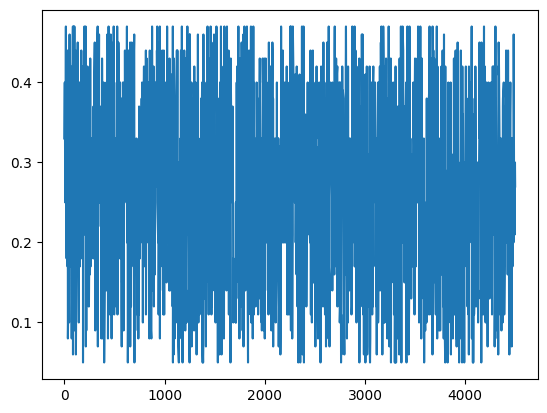

In [23]:
df_05.SN_ellip_dist.plot()

In [13]:
df.SN_ellip_dist.max()

np.float64(1.0)

In [24]:
cinco_por_galaxia = df.groupby('gal_objectId').head(5)
cinco_por_galaxia

,gal_objectId,gal_band,gal_visit,gal_detector,diff_sourceId,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path
0,611256378312376542,z,2024120800360,8,592913913020940296,z,2024111700354,4,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...","[[32.616245, -31.05905, -51.33175, 83.870514, ...","[[-21.633503, -69.30557, 24.623798, 66.54024, ...",simulated_data/fakes/611256378312376542_z_2024...
1,609780833707896898,g,2024112900266,0,650018217640591465,g,2024112600116,4,0.88,"[[210.51036, 194.16635, 226.60606, 208.87112, ...","[[4.6535196, -7.1084204, 15.935069, -5.0868855...","[[205.85684, 201.27477, 210.67099, 213.95801, ...",simulated_data/fakes/609780833707896898_g_2024...
2,611255691117605475,r,2024113000163,3,614437609048899879,r,2024112600305,1,0.74,"[[-24.263647, 23.363667, -8.025528, 55.17688, ...","[[-10.19281, 19.809084, -1.9615426, 28.060669,...","[[-14.070837, 3.5545833, -6.063985, 27.116209,...",simulated_data/fakes/611255691117605475_r_2024...
3,611255622398132035,i,2024120300157,8,648363383921311853,i,2024112300236,6,0.90,"[[60.298386, -91.77385, 44.987007, -35.799484,...","[[37.04548, -36.984486, 48.095524, -9.511111, ...","[[23.252905, -54.789364, -3.108515, -26.288372...",simulated_data/fakes/611255622398132035_i_2024...
4,609788117972430021,i,2024111900089,8,650018148921114792,i,2024112600128,5,0.57,"[[64.394684, 132.19717, -14.009651, 126.18045,...","[[-16.556696, 32.335075, -49.94117, 25.10089, ...","[[80.95138, 99.86209, 35.93152, 101.07956, 159...",simulated_data/fakes/609788117972430021_i_2024...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4207,609788255411391107,z,2024120700337,0,612929079095591353,z,2024120900471,6,1.00,"[[224.30891, -33.865326, 6.9801407, 68.73816, ...","[[110.7932, -29.94855, -26.09108, -59.344803, ...","[[113.51572, -3.9167752, 33.07122, 128.08296, ...",simulated_data/fakes/609788255411391107_z_2024...
4250,609788873886679149,r,2024120300118,6,614437609048899658,r,2024120300100,0,0.50,"[[3.8641863, -20.829483, -18.070633, -17.20253...","[[11.748679, -32.46899, 0.23144123, -24.570013...","[[-7.884493, 11.639507, -18.302074, 7.3674817,...",simulated_data/fakes/609788873886679149_r_2024...
4378,609788736447730238,i,2024120300132,6,650018836115882078,i,2024112300243,1,1.00,"[[88.14358, -7.7519093, -75.71553, 51.676178, ...","[[41.66538, 19.687435, -118.33203, 25.975534, ...","[[46.4782, -27.439344, 42.616497, 25.700644, -...",simulated_data/fakes/609788736447730238_i_2024...
4401,611255759837084227,r,2024120300146,2,648365582944567320,r,2024112300214,4,0.50,"[[-31.276003, -40.35616, 32.78255, 26.583775, ...","[[-11.816378, 2.9092574, 20.763266, 13.437313,...","[[-19.459625, -43.265415, 12.019285, 13.146462...",simulated_data/fakes/611255759837084227_r_2024...


In [ ]:
# 4 arcseg

In [7]:
df = df.rename(columns={'gal_objectId': 'oid', 'diff_sourceId': 'measurement_id'})
df.head()

,oid,gal_band,gal_visit,gal_detector,measurement_id,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path
0,611256378312376542,z,2024120800360,8,592913913020940296,z,2024111700354,4,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...","[[32.616245, -31.05905, -51.33175, 83.870514, ...","[[-21.633503, -69.30557, 24.623798, 66.54024, ...",simulated_data/fakes/611256378312376542_z_2024...
1,609780833707896898,g,2024112900266,0,650018217640591465,g,2024112600116,4,0.88,"[[210.51036, 194.16635, 226.60606, 208.87112, ...","[[4.6535196, -7.1084204, 15.935069, -5.0868855...","[[205.85684, 201.27477, 210.67099, 213.95801, ...",simulated_data/fakes/609780833707896898_g_2024...
2,611255691117605475,r,2024113000163,3,614437609048899879,r,2024112600305,1,0.74,"[[-24.263647, 23.363667, -8.025528, 55.17688, ...","[[-10.19281, 19.809084, -1.9615426, 28.060669,...","[[-14.070837, 3.5545833, -6.063985, 27.116209,...",simulated_data/fakes/611255691117605475_r_2024...
3,611255622398132035,i,2024120300157,8,648363383921311853,i,2024112300236,6,0.90,"[[60.298386, -91.77385, 44.987007, -35.799484,...","[[37.04548, -36.984486, 48.095524, -9.511111, ...","[[23.252905, -54.789364, -3.108515, -26.288372...",simulated_data/fakes/611255622398132035_i_2024...
4,609788117972430021,i,2024111900089,8,650018148921114792,i,2024112600128,5,0.57,"[[64.394684, 132.19717, -14.009651, 126.18045,...","[[-16.556696, 32.335075, -49.94117, 25.10089, ...","[[80.95138, 99.86209, 35.93152, 101.07956, 159...",simulated_data/fakes/609788117972430021_i_2024...


In [8]:
df.oid.nunique()

175

In [27]:
for row in df['flux_Science_data']:
    print(row.shape)

(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(

In [28]:
for row in df['flux_Difference_data']:
    print(row.shape)

(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(

In [ ]:
## Para probar la calidad de las simulaciones
# Train --> Simuladas
# Val --> Simuladas
# Test --> Real

## Para probar (con porcentaje de peso para los datos)
# Train --> Real + Simuladas
# Val --> Real + Simuladas
# Test --> Real